In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp, quad
from scipy.sparse import diags
from matplotlib.animation import FuncAnimation
from IPython.display import HTML
import numpy as np
from scipy.linalg import eigvalsh
from scipy.integrate import simps
from scipy.optimize import root, root_scalar
import numpy as np
from scipy.linalg import eigvals

In [2]:
import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)

In [3]:
import matplotlib.pyplot as plt

plt.rcParams.update({
    "font.size": 22,          # base font
    "axes.titlesize": 24,
    "axes.labelsize": 22,
    "xtick.labelsize": 20,
    "ytick.labelsize": 20,
    "legend.fontsize": 20,
    "figure.titlesize": 24,
})

# Auxiliary functions

In [9]:
import numpy as np
from scipy.linalg import eigvals

def construct_advection_operator(N, dx, v):

    A = np.zeros((N, N))
    for i in range(1, N - 1):
        A[i, i - 1] = -v[i] / (2 * dx)
        A[i, i + 1] = +v[i] / (2 * dx)
    return A


def estimate_principal_eigenvalue_variable_D_advection(D_func, v_func, g_func, N=100, L=1.0):

    
    x = np.linspace(0, L, N)
    dx = x[1] - x[0]

    D = D_func(x)
    v = v_func(x)
    g = g_func(x)

    diffusion_op = construct_neumann_laplacian_variable_D(N, dx, D)
    advection_op = construct_advection_operator(N, dx, v)
    reaction_op = np.diag(g)

    # Correct sign for advection and nonsymmetric eigenvalue solver
    L_op = diffusion_op + advection_op + reaction_op

    eigenvalues = eigvals(L_op)
    principal_eigenvalue = np.max(np.real(eigenvalues))
    return principal_eigenvalue

def construct_advection_operator(N, dx, v):

    A = np.zeros((N, N))
    for i in range(1, N - 1):
        A[i, i - 1] = -v[i] / (2 * dx)
        A[i, i + 1] = +v[i] / (2 * dx)
    return A

def construct_neumann_laplacian_variable_D(N, dx, D):

    A = np.zeros((N, N))

    for i in range(1, N - 1):
        D_iphalf = 0.5 * (D[i] + D[i + 1])
        D_iminushalf = 0.5 * (D[i] + D[i - 1])

        A[i, i - 1] = D_iminushalf / dx**2
        A[i, i] = - (D_iphalf + D_iminushalf) / dx**2
        A[i, i + 1] = D_iphalf / dx**2

    # Neumann BC at left boundary (i = 0)
    D_phalf = 0.5 * (D[0] + D[1])
    A[0, 0] = -D_phalf / dx**2
    A[0, 1] = D_phalf / dx**2

    # Neumann BC at right boundary (i = N - 1)
    D_mhalf = 0.5 * (D[N - 1] + D[N - 2])
    A[N - 1, N - 2] = D_mhalf / dx**2
    A[N - 1, N - 1] = -D_mhalf / dx**2

    return A

def estimate_principal_eigenvalue_variable_D_advection(D_func, v_func, g_func, N=100, L=1.0):

    x = np.linspace(0, L, N)
    dx = x[1] - x[0]

    D = D_func(x)
    v = v_func(x)
    g = g_func(x)

    diffusion_op = construct_neumann_laplacian_variable_D(N, dx, D)
    advection_op = construct_advection_operator(N, dx, v)
    reaction_op = np.diag(g)

    # Correct sign for advection and nonsymmetric eigenvalue solver
    L_op = diffusion_op + advection_op + reaction_op

    eigenvalues = eigvals(L_op)
    principal_eigenvalue = np.max(np.real(eigenvalues))
    return principal_eigenvalue

def join_figures_side_by_side(figs, labels=("A", "B", "C"), figsize=(18, 6)):
    images = [fig_to_image(fig, dpi=1200) for fig in figs]

    fig, axes = plt.subplots(1, len(images), figsize=figsize)

    if len(images) == 1:
        axes = [axes]

    for ax, img, label in zip(axes, images, labels):
        ax.imshow(img)
        ax.axis("off")

        ax.text(
            0.02, 0.98, label,
            transform=ax.transAxes,
            fontweight="bold",
            va="top",
            ha="left"
        )

    plt.tight_layout()
    return fig


import numpy as np
import matplotlib.pyplot as plt


def join_axes_grid(
    figs,
    labels=("A", "B", "C", "D", "E", "F"),
    nrows=2,
    ncols=3,
    figsize=None,
    width_per_panel=5.5,
    height_per_panel=4.5,
    keep_limits=True,
    keep_labels=True,
    panel_fontsize=20,
    panel_dx=-0.10,
    panel_dy=1.08,
    legend=True,
):


    n_panels = nrows * ncols

    if len(figs) > n_panels:
        raise ValueError(f"Too many figures: got {len(figs)}, but grid has only {n_panels} panels.")

    if figsize is None:
        figsize = (width_per_panel * ncols, height_per_panel * nrows)

    out_fig, out_axes = plt.subplots(nrows, ncols, figsize=figsize, squeeze=False)
    flat_axes = out_axes.ravel()

    for i, dst_ax in enumerate(flat_axes):
        if i >= len(figs):
            dst_ax.axis("off")
            continue

        src_fig = figs[i]
        src_ax = src_fig.axes[0]

        # ------------------------------------------------------------
        # Copy lines
        # ------------------------------------------------------------
        for line in src_ax.get_lines():
            dst_ax.plot(
                line.get_xdata(),
                line.get_ydata(),
                linestyle=line.get_linestyle(),
                linewidth=line.get_linewidth(),
                marker=line.get_marker(),
                markersize=line.get_markersize(),
                color=line.get_color(),
                alpha=line.get_alpha(),
                zorder=line.get_zorder(),
                label=line.get_label(),
            )

        # ------------------------------------------------------------
        # Copy labels/titles
        # ------------------------------------------------------------
        if keep_labels:
            dst_ax.set_title(src_ax.get_title())
            dst_ax.set_xlabel(src_ax.get_xlabel())
            dst_ax.set_ylabel(src_ax.get_ylabel())

        # ------------------------------------------------------------
        # Copy limits
        # ------------------------------------------------------------
        if keep_limits:
            dst_ax.set_xlim(src_ax.get_xlim())
            dst_ax.set_ylim(src_ax.get_ylim())

        # ------------------------------------------------------------
        # Copy grid
        # ------------------------------------------------------------
        grid_visible = (
            any(gl.get_visible() for gl in src_ax.get_xgridlines())
            or any(gl.get_visible() for gl in src_ax.get_ygridlines())
        )
        if grid_visible:
            dst_ax.grid(True, alpha=0.3)

        # ------------------------------------------------------------
        # Copy legend
        # ------------------------------------------------------------
        if legend:
            handles, labels_ = dst_ax.get_legend_handles_labels()

            # remove empty/private labels
            cleaned = [
                (h, lab)
                for h, lab in zip(handles, labels_)
                if lab and not lab.startswith("_")
            ]

            if cleaned:
                handles_clean, labels_clean = zip(*cleaned)
                dst_ax.legend(handles_clean, labels_clean)

        # ------------------------------------------------------------
        # Panel label
        # ------------------------------------------------------------
        if i < len(labels) and labels[i] is not None:
            dst_ax.text(
                panel_dx,
                panel_dy,
                labels[i],
                transform=dst_ax.transAxes,
                fontsize=panel_fontsize,
                fontweight="bold",
                va="top",
                ha="left",
                clip_on=False,
            )

    out_fig.tight_layout()
    out_fig.subplots_adjust(left=0.06, right=0.98, top=0.94, bottom=0.08, wspace=0.32, hspace=0.35)

    return out_fig, out_axes

def join_axes_side_by_side(
    figs,
    labels=("A", "B", "C"),
    figsize=None,
    width_per_panel=6,
    height=5,
    keep_limits=True,
    keep_labels=True,
    panel_fontsize=18,
    panel_dx=-0.08,
    panel_dy=1.02,
):
    n = len(figs)

    if figsize is None:
        figsize = (width_per_panel * n, height)

    out_fig, out_axes = plt.subplots(1, n, figsize=figsize, squeeze=False)
    out_axes = out_axes[0]

    for i, (src_fig, dst_ax) in enumerate(zip(figs, out_axes)):
        src_ax = src_fig.axes[0]

        # ---- Copy lines
        for line in src_ax.get_lines():
            dst_ax.plot(
                line.get_xdata(),
                line.get_ydata(),
                linestyle=line.get_linestyle(),
                linewidth=line.get_linewidth(),
                marker=line.get_marker(),
                markersize=line.get_markersize(),
                color=line.get_color(),
                alpha=line.get_alpha(),
                zorder=line.get_zorder(),
                label=line.get_label(),
            )

        # ---- Clone QuadMesh collections (pcolormesh)
        for coll in src_ax.collections:
            if isinstance(coll, QuadMesh):
                _clone_quadmesh(coll, dst_ax)

        # ---- Copy labels/titles
        if keep_labels:
            dst_ax.set_title(src_ax.get_title())
            dst_ax.set_xlabel(src_ax.get_xlabel())
            dst_ax.set_ylabel(src_ax.get_ylabel())

        # ---- Copy limits
        if keep_limits:
            dst_ax.set_xlim(src_ax.get_xlim())
            dst_ax.set_ylim(src_ax.get_ylim())

        # ---- Copy grid visibility
        grid_visible = (
            any(gl.get_visible() for gl in src_ax.get_xgridlines())
            or any(gl.get_visible() for gl in src_ax.get_ygridlines())
        )
        if grid_visible:
            dst_ax.grid(True)

        # ---- Copy legend if present
        handles, labels_ = src_ax.get_legend_handles_labels()
        if handles:
            dst_ax.legend(handles, labels_)

        # ---- Panel label
        label = labels[i] if i < len(labels) else None
        if label:
            dst_ax.text(
                panel_dx,
                panel_dy,
                label,
                transform=dst_ax.transAxes,
                fontsize=panel_fontsize,
                fontweight="bold",
                va="top",
                ha="left",
                clip_on=False,
            )

    out_fig.tight_layout()
    out_fig.subplots_adjust(left=0.08, top=0.92)

    return out_fig

In [10]:
#Example

x = np.linspace(0, 1 ,200)
#NO BACKWARD BIFURCATION
D_func=lambda x: (1 + 0. * x) * 1e-2
v_func=lambda x: 0 * x
g_func=lambda x: 0.5 - 2 * x**2


estimate_principal_eigenvalue_variable_D_advection(
    D_func, v_func, g_func, N=1001)

0.35887929034493027

# Function to Plot Steady States

In [65]:
#Plotting solution at a certain T
def plot_sol(
    lambda12_base,
    lambda21,
    L=1.0,
    Nx=200,
    D_func=lambda x: 0.01 + 0*x,
    v_func=lambda x: 0*x,
    T=1000,
    tolerance=1e-4,
    a=0,
    z0=None,
    ax=None
):
    if z0 is None:
        z0 = 0.5 * np.ones(Nx)

    # Spatial grid
    x = np.linspace(0, L, Nx)
    dx = x[1] - x[0]

    # Coefficients
    D = D_func(x)
    v = v_func(x)

    # Operators
    lap = construct_neumann_laplacian_variable_D(Nx, dx, D)
    adv = construct_advection_operator(Nx, dx, v)

    lambda12 = lambda x: a * lambda12_base(x)

    def rhs(t, z):
        lam12 = lambda12(x)
        lam21_val = lambda21(x)
        reaction = z * (1 - z) * (lam12 - (lam12 + lam21_val) * z)
        return reaction + lap.dot(z) + adv.dot(z)

    sol = solve_ivp(rhs, [0, T], z0, method='BDF', t_eval=[T])

    # Create axes if none provided
    if ax is None:
        fig, ax = plt.subplots()
    else:
        fig = ax.figure

    ax.plot(x, sol.y[:, -1], label='z(x, T)')
    ax.set_xlabel('x')
    ax.set_ylabel('z')
    ax.set_xlim(-0.05, 1.05)
    ax.set_ylim(-0.05, 1.05)
    ax.grid(True, alpha=0.3)
    ax.tick_params(axis='both')
    ax.legend()


    return fig, ax


In [66]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

def plot_sol_evolution(
    lambda12_base,
    lambda21,
    L=1.0,
    Nx=200,
    D_func=lambda x: 0.01 + 0*x,
    v_func=lambda x: 0*x,
    T=1000,
    tolerance=1e-4,
    a=0,
    z0=None,
    ax=None,
    t_samples=4,          # int -> number of curves, OR array-like times
    t_min=0.0,            # used only if t_samples is an int
    legend=False
):

    

    if z0 is None:
        z0 = 0.5 * np.ones(Nx)

    # Spatial grid
    x = np.linspace(0, L, Nx)
    dx = x[1] - x[0]

    # Coefficients
    D = D_func(x)
    v = v_func(x)

    # Operators (assumed defined elsewhere, as in your code)
    lap = construct_neumann_laplacian_variable_D(Nx, dx, D)
    adv = construct_advection_operator(Nx, dx, v)

    lambda12 = lambda x: a * lambda12_base(x)

    def rhs(t, z):
        lam12 = lambda12(x)
        lam21_val = lambda21(x)
        reaction = z * (1 - z) * (lam12 - (lam12 + lam21_val) * z)
        return reaction + lap.dot(z) + adv.dot(z)

    # Choose times to plot
    if np.isscalar(t_samples):
        n = int(t_samples)
        if n < 2:
            raise ValueError("t_samples as an int must be >= 2.")
        t_eval = np.linspace(t_min, T, n)
    else:
        t_eval = np.asarray(t_samples, dtype=float)
        if np.any(t_eval < 0) or np.any(t_eval > T):
            raise ValueError("All times in t_samples must satisfy 0 <= t <= T.")
        t_eval = np.unique(t_eval)  # sorted unique

    # Solve with multiple evaluation times
    sol = solve_ivp(
        rhs,
        (0, T),
        z0,
        method="BDF",
        t_eval=t_eval,
        rtol=tolerance,
        atol=tolerance,
    )

    if not sol.success:
        raise RuntimeError(f"solve_ivp failed: {sol.message}")

    # Create axes if none provided
    if ax is None:
        fig, ax = plt.subplots()
    else:
        fig = ax.figure


    n_curves = len(sol.t)
    
    cmap = plt.cm.Blues  # or viridis, plasma, etc.
    colors = cmap(np.linspace(0.35, 0.9, n_curves))
    
    # Optional: make final curve black (recommended for steady state)
    colors[-1] = np.array([0, 0, 0, 1])
    
    # --- Plot snapshots ---
    for j, t in enumerate(sol.t):
        lbl = f"t={t:g}" if legend else "_nolegend_"
        ax.plot(x, sol.y[:, j], color=colors[j], label=lbl, linewidth=4)

    ax.set_xlabel("x")
    ax.set_ylabel("z(x,t)")
    ax.set_xlim(-0.05, L + 0.05)
    ax.set_ylim(-0.05, 1.05)
    ax.grid(True, alpha=0.3)

    return fig, ax

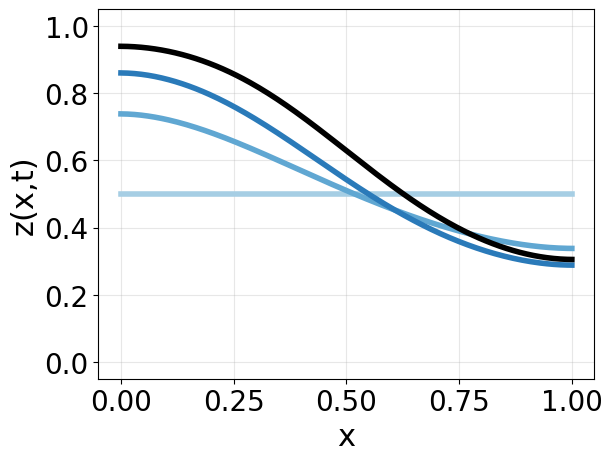

In [67]:
lambda12_base = lambda x: 0.5 - x
lambda21 = lambda x: -0.5 + 1*x

fig, ax = plot_sol_evolution(lambda12_base, lambda21, T=1000, t_samples=[0, 5, 10, 1000])

# Plotting lambda functions

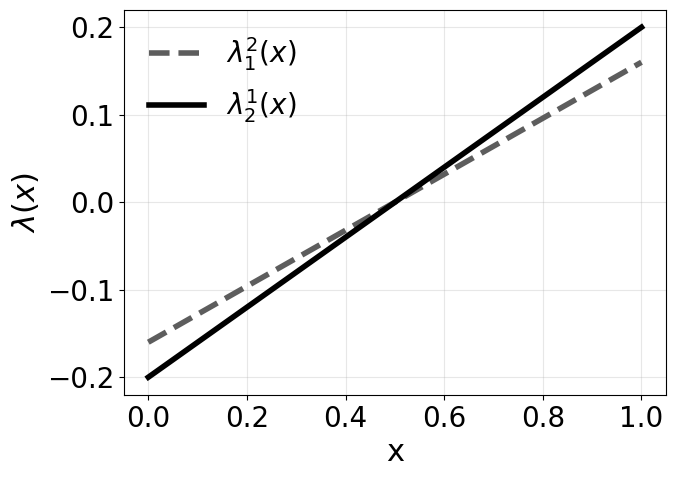

In [14]:
import numpy as np
import matplotlib.pyplot as plt

# Functions
lambda12_base = lambda x: 2 * (-0.8 * (0.1 - 0.2 * x))
lambda21_example = lambda x: 2 * (-0.1 + 0.2 * x)

def plot_lambda_functions(
    lambda12_base,
    lambda21,
    L=1.0,
    Nx=200,
    ax=None,
    legend=True
):
    x = np.linspace(0, L, Nx)

    y1 = lambda12_base(x)
    y2 = lambda21(x)

    if ax is None:
        fig, ax = plt.subplots(figsize=(7, 5))
    else:
        fig = ax.figure

    # Similar style to your evolution plot
    cmap = plt.cm.Blues
    colors = cmap(np.linspace(0.5, 0.85, 2))
    colors[-1] = np.array([0, 0, 0, 1])  # second curve black

    ax.plot(x, y1, color="#5d5d5d", linewidth=4, ls="--",
            label=r"$\lambda_1^2(x)$")
    
    ax.plot(x, y2, color="black", linewidth=4,
            label=r"$\lambda_2^1(x)$")

    ax.set_xlabel("x")
    ax.set_ylabel(r"$\lambda(x)$")
    ax.set_xlim(-0.05, L + 0.05)

    ymin = min(y1.min(), y2.min())
    ymax = max(y1.max(), y2.max())
    pad = 0.05 * (ymax - ymin if ymax > ymin else 1.0)
    ax.set_ylim(ymin - pad, ymax + pad)

    ax.grid(True, alpha=0.3)

    if legend:
        ax.legend(frameon=False)

    return fig, ax

# Example usage
fig, ax = plot_lambda_functions(lambda12_base, lambda21_example)
plt.show()

# Section 2 figures - plotting interesting steady states

## Quadrant I

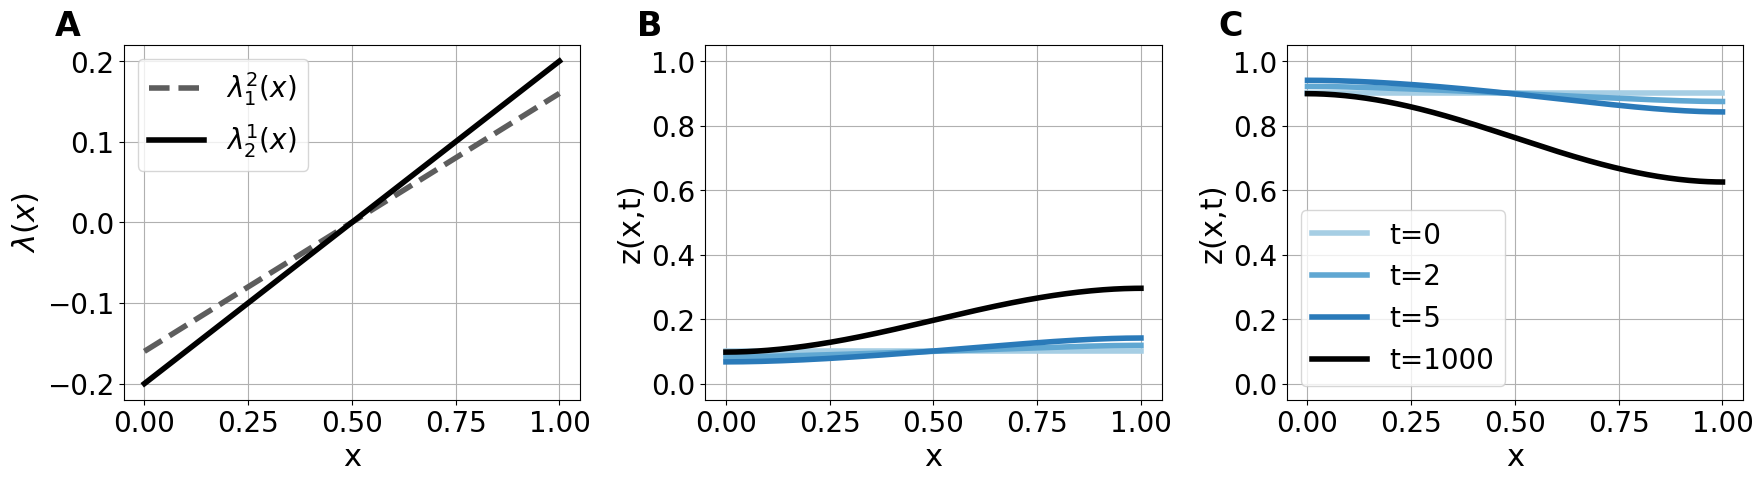

In [12]:
lambda12_base = lambda x: -0.16 + 0.32 * x

lambda21_example = lambda x: -0.2 + 0.4 * x

D_func = lambda x: (1 + 0*x) * 1e-2
v_func = lambda x: 0 * x


example1, _ = fig, ax = plot_lambda_functions(lambda12_base, lambda21_example)
plt.close(example1)


example2, _ = plot_sol_evolution(
    lambda12_base=lambda12_base,
    lambda21=lambda21_example,
    D_func=D_func,
    v_func=v_func,
    a= 1,
    L=1.0,
    Nx=200,
    T=1000,
    z0 = np.ones(200)*0.1,
    t_samples=[0, 2, 5, 1000]
)
plt.close(example2)


example3, _ = plot_sol_evolution(
    lambda12_base=lambda12_base,
    lambda21=lambda21_example,
    D_func=D_func,
    v_func=v_func,
    a= 1,
    L=1.0,
    Nx=200,
    T=1000,
    z0 = np.ones(200)*0.9,
    t_samples=[0, 2, 5, 1000],
    legend=True
)
plt.close(example3)

fig = join_axes_side_by_side([example1, example2, example3],
                             labels=("A","B","C"),
                             panel_fontsize=24,
                             panel_dx=-0.15,
                             panel_dy=1.1)

#fig.savefig("1stquadrantalternative.pdf", bbox_inches="tight")

## Quadrant II and IV

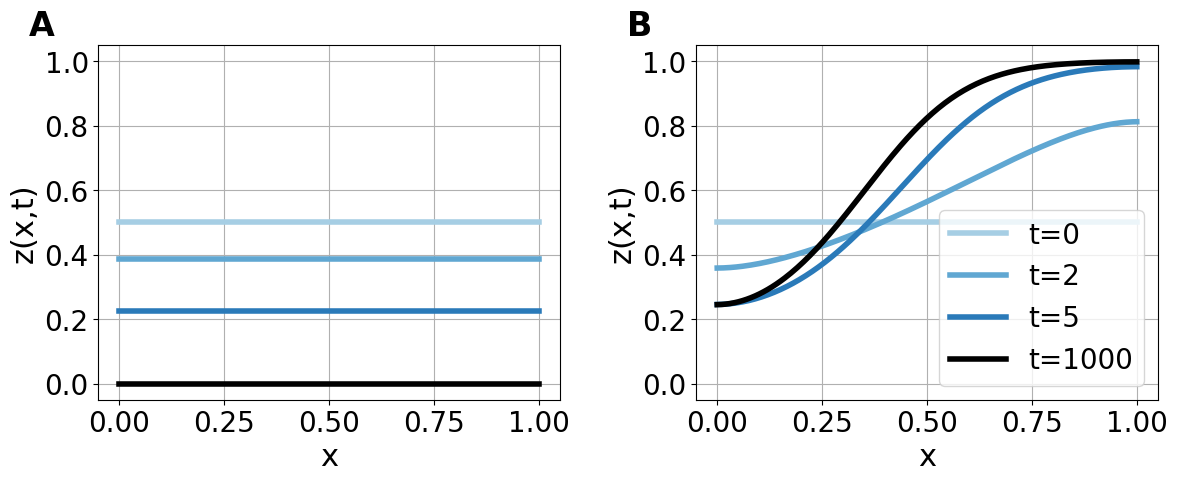

In [18]:
lambda12_base = lambda x: -0.3
lambda21_example = lambda x: 0.15

D_func = lambda x: (1 + 0*x) * 1e-2
v_func = lambda x: 0 * x


example1, _ = plot_sol_evolution(
    lambda12_base=lambda12_base,
    lambda21=lambda21_example,
    D_func=D_func,
    v_func=v_func,
    a= 1,
    L=1.0,
    Nx=200,
    T=1000,
    z0 = 0.5*np.ones(200),
    t_samples=[0, 2, 5, 1000]
)
plt.close(example1)


lambda12_base = lambda x: -0.3
lambda21_example = lambda x: 0.5-2*x



example2, _ = plot_sol_evolution(
    lambda12_base=lambda12_base,
    lambda21=lambda21_example,
    D_func=D_func,
    v_func=v_func,
    a= 1,
    L=1.0,
    Nx=200,
    T=1000,
    z0 = 0.5*np.ones(200),
    t_samples=[0, 2, 5, 1000],
    legend=True
)


plt.close(example2)

fig = join_axes_side_by_side([example1, example2],
                             labels=("A","B"),
                             panel_fontsize=24,
                             panel_dx=-0.15,
                             panel_dy=1.1)
#fig.savefig("2ndquadrantexamples.pdf", bbox_inches="tight")       # PDF

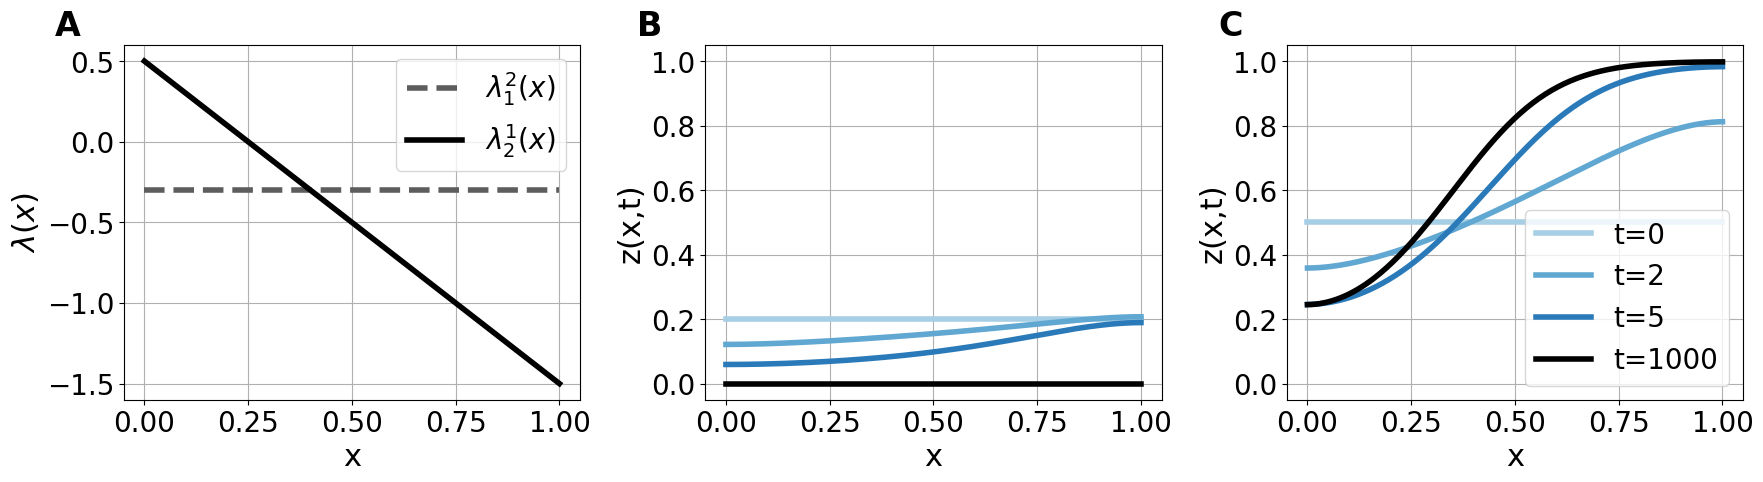

In [19]:
lambda12_base = lambda x: -0.3 + 0*x
lambda21_example = lambda x: 0.5-2*x

D_func = lambda x: (1 + 0*x) * 1e-2
v_func = lambda x: 0 * x

example1, _ = fig, ax = plot_lambda_functions(lambda12_base, lambda21_example)
plt.close(example1)

example2, _ = plot_sol_evolution(
    lambda12_base=lambda12_base,
    lambda21=lambda21_example,
    D_func=D_func,
    v_func=v_func,
    a= 1,
    L=1.0,
    Nx=200,
    T=1000,
    z0 = 0.2*np.ones(200),
    t_samples=[0, 2, 5, 1000]
)
plt.close(example2)


lambda12_base = lambda x: -0.3
lambda21_example = lambda x: 0.5-2*x



example3, _ = plot_sol_evolution(
    lambda12_base=lambda12_base,
    lambda21=lambda21_example,
    D_func=D_func,
    v_func=v_func,
    a= 1,
    L=1.0,
    Nx=200,
    T=1000,
    z0 = 0.5*np.ones(200),
    t_samples=[0, 2, 5, 1000],
    legend=True
)


plt.close(example3)

fig = join_axes_side_by_side([example1, example2, example3],
                             labels=("A","B","C"),
                             panel_fontsize=24,
                             panel_dx=-0.15,
                             panel_dy=1.1)
#fig.savefig("2ndquadrantexamples_2.pdf", bbox_inches="tight")       # PDF

## Quadrant III

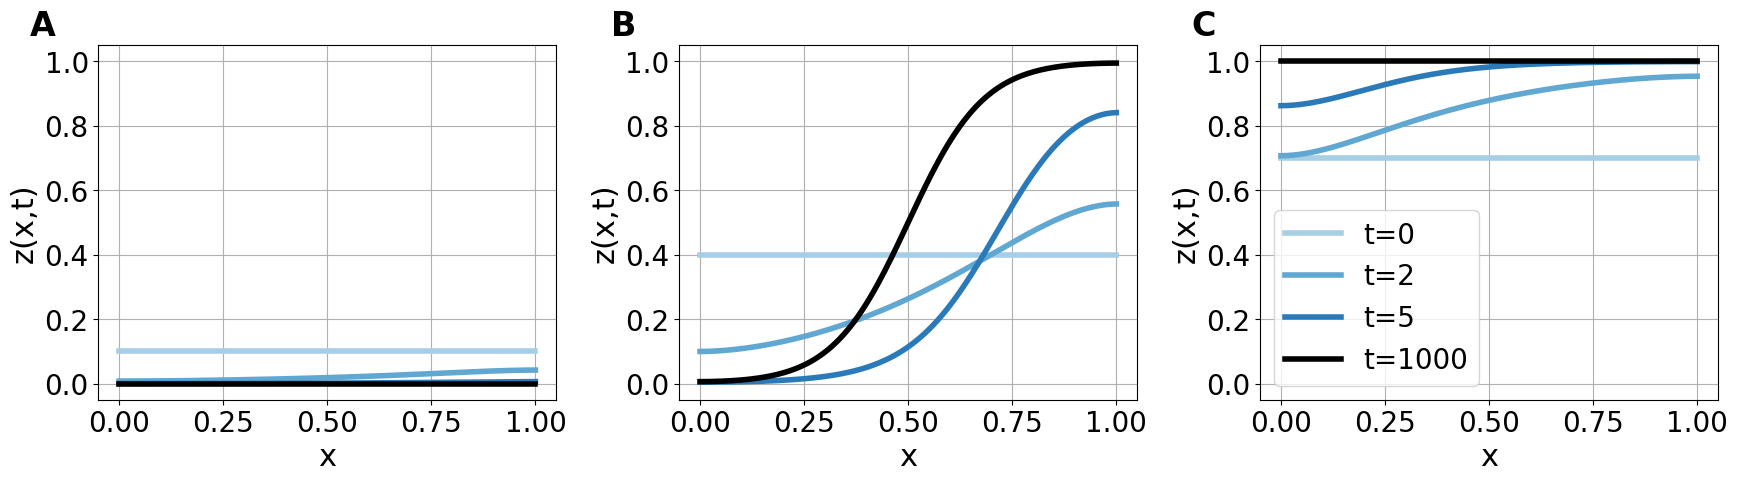

In [20]:
lambda12_base = lambda x: -1.5 + x
lambda21_example = lambda x: -x - 0.5

D_func = lambda x: (1 + 0*x) * 1e-2
v_func = lambda x: 0 * x


example1, _ = plot_sol_evolution(
    lambda12_base=lambda12_base,
    lambda21=lambda21_example,
    D_func=D_func,
    v_func=v_func,
    a= 1,
    L=1.0,
    Nx=200,
    T=1000,
    z0 = np.ones(200)*0.1,
    t_samples=[0, 2, 5, 1000]
)
plt.close(example1)


example2, _ = plot_sol_evolution(
    lambda12_base=lambda12_base,
    lambda21=lambda21_example,
    D_func=D_func,
    v_func=v_func,
    a= 1,
    L=1.0,
    Nx=200,
    T=1000,
    z0 = np.ones(200)*0.4,
    t_samples=[0, 2, 5, 1000]
)
plt.close(example2)


example3, _ = plot_sol_evolution(
    lambda12_base=lambda12_base,
    lambda21=lambda21_example,
    D_func=D_func,
    v_func=v_func,
    a= 1,
    L=1.0,
    Nx=200,
    T=1000,
    z0 = np.ones(200)*0.7,
    t_samples=[0, 2, 5, 1000],
    legend=True
)
plt.close(example3)

fig = join_axes_side_by_side([example1, example2, example3],
                             labels=("A","B","C"),
                             panel_fontsize=24,
                             panel_dx=-0.15,
                             panel_dy=1.1)

#fig.savefig("3rdquadrantexamples.pdf", bbox_inches="tight")

# SIS Figure

In [68]:
def plot_sol_evolutiontheta(
    lambda12_base,
    lambda21,
    L=1.0,
    Nx=200,
    D_func=lambda x: 0.01 + 0*x,
    v_func=lambda x: 0*x,
    T=1000,
    tolerance=1e-4,
    a=0,
    z0=None,
    ax=None,
    t_samples=4,          # int -> number of curves, OR array-like times
    t_min=0.0,            # used only if t_samples is an int
    legend=False,
    theta = 0
):

    

    if z0 is None:
        z0 = 0.5 * np.ones(Nx)

    # Spatial grid
    x = np.linspace(0, L, Nx)
    dx = x[1] - x[0]

    # Coefficients
    D = D_func(x)
    v = v_func(x)

    # Operators (assumed defined elsewhere, as in your code)
    lap = construct_neumann_laplacian_variable_D(Nx, dx, D)
    adv = construct_advection_operator(Nx, dx, v)

    lambda12 = lambda x: a * lambda12_base(x)

    def rhs(t, z):
        lam12 = lambda12(x)
        lam21_val = lambda21(x)
        reaction = z * (1 - z) * (lam12 - (lam12 + lam21_val) * z)
        return theta * reaction + lap.dot(z) + adv.dot(z)

    # Choose times to plot
    if np.isscalar(t_samples):
        n = int(t_samples)
        if n < 2:
            raise ValueError("t_samples as an int must be >= 2.")
        t_eval = np.linspace(t_min, T, n)
    else:
        t_eval = np.asarray(t_samples, dtype=float)
        if np.any(t_eval < 0) or np.any(t_eval > T):
            raise ValueError("All times in t_samples must satisfy 0 <= t <= T.")
        t_eval = np.unique(t_eval)  # sorted unique

    # Solve with multiple evaluation times
    sol = solve_ivp(
        rhs,
        (0, T),
        z0,
        method="BDF",
        t_eval=t_eval,
        rtol=tolerance,
        atol=tolerance,
    )

    if not sol.success:
        raise RuntimeError(f"solve_ivp failed: {sol.message}")

    # Create axes if none provided
    if ax is None:
        fig, ax = plt.subplots()
    else:
        fig = ax.figure


    n_curves = len(sol.t)
    
    cmap = plt.cm.Blues  # or viridis, plasma, etc.
    colors = cmap(np.linspace(0.35, 0.9, n_curves))
    
    # Optional: make final curve black (recommended for steady state)
    colors[-1] = np.array([0, 0, 0, 1])
    
    # --- Plot snapshots ---
    for j, t in enumerate(sol.t):
        lbl = f"t={t:g}" if legend else "_nolegend_"
        ax.plot(x, sol.y[:, j], color=colors[j], label=lbl, linewidth=4)

    ax.set_xlabel("x")
    ax.set_ylabel("z(x,t)")
    ax.set_xlim(-0.05, L + 0.05)
    ax.set_ylim(-0.05, 1.05)
    ax.grid(True, alpha=0.3)

    return fig, ax

In [69]:
import numpy as np


def slow_diffusion_from_table1(
    beta, gamma, r, k, eps,
    b, nu, u, omega, alpha,
    chi=(1, 1, 1, 1, 1),
    dx=None,
    check=True,
):
    """
    Compute slow-diffusion pairwise fitness coefficients lambda_i^j(x)
    from the Table 1 parametrization in Le & Madec.

    Table 1 parametrization:
        beta_i    = beta  * (1 + eps * b_i)
        gamma_i   = gamma * (1 + eps * nu_i)
        gamma_ij  = gamma * (1 + eps * u_ij)
        p^s_ij    = 1/2 + eps * omega^s_ij
        k_ij      = k + eps * alpha_ij

    Convention:
        Lambda[i, j, ...] = lambda_i^j(x)

    For two strains:
        Lambda[0, 1] = lambda_1^2
        Lambda[1, 0] = lambda_2^1

    Parameters
    ----------
    beta, gamma, r, k : scalar or array_like
        Neutral spatial parameters beta(x), gamma(x), r(x), k(x).

    eps : float
        Small quasi-neutral parameter epsilon.

    b, nu : array_like
        Shape (N, ...). Perturbations b_i(x), nu_i(x).

    u, alpha : array_like
        Shape (N, N, ...). Perturbations u_ij(x), alpha_ij(x).

    omega : array_like
        Shape (N, N, N, ...), with omega[s, i, j, ...] = omega^s_ij(x).

    chi : tuple of five 0/1 values
        Switches for the five perturbation types.
        Default (1,1,1,1,1) means all Table 1 perturbations are included.

    dx : float or None
        If supplied and the spatial domain is 1D, the function also computes
        the advection coefficient vartheta(x) using np.gradient.

    check : bool
        If True, performs basic consistency checks.

    Returns
    -------
    Lambda : ndarray
        Pairwise fitness matrix, shape (N, N, ...).

    params : dict
        Full strain-specific parameters:
            beta_i, gamma_i, gamma_ij, p, k_ij.

    aux : dict
        Neutral quantities, weights, and optionally vartheta.
    """

    beta = np.asarray(beta, dtype=float)
    gamma = np.asarray(gamma, dtype=float)
    r = np.asarray(r, dtype=float)
    k = np.asarray(k, dtype=float)

    b = np.asarray(b, dtype=float)
    nu = np.asarray(nu, dtype=float)
    u = np.asarray(u, dtype=float)
    omega = np.asarray(omega, dtype=float)
    alpha = np.asarray(alpha, dtype=float)

    chi1, chi2, chi3, chi4, chi5 = chi

    N = b.shape[0]

    if check:
        if nu.shape[0] != N:
            raise ValueError("nu should have shape (N, ...), with the same N as b.")
        if u.shape[:2] != (N, N):
            raise ValueError("u should have shape (N, N, ...).")
        if alpha.shape[:2] != (N, N):
            raise ValueError("alpha should have shape (N, N, ...).")
        if omega.shape[:3] != (N, N, N):
            raise ValueError("omega should have shape (N, N, N, ...), with omega[s, i, j].")
        if len(chi) != 5:
            raise ValueError("chi should be a tuple/list of five 0/1 values.")

    # ------------------------------------------------------------
    # Full Table 1 strain-specific parameters
    # ------------------------------------------------------------
    beta_i = beta * (1.0 + eps * b)
    gamma_i = gamma * (1.0 + eps * nu)
    gamma_ij = gamma * (1.0 + eps * u)
    p = 0.5 + eps * omega
    k_ij = k + eps * alpha

    params = {
        "beta_i": beta_i,
        "gamma_i": gamma_i,
        "gamma_ij": gamma_ij,
        "p": p,
        "k_ij": k_ij,
    }

    # ------------------------------------------------------------
    # Neutral endemic quantities
    # ------------------------------------------------------------
    m = r + gamma
    R0 = beta / m

    if check and np.any(R0 <= 1):
        raise ValueError("Slow diffusion case assumes R0(x)=beta(x)/(r(x)+gamma(x)) > 1.")

    Sstar = m / beta
    Tstar = 1.0 - Sstar

    Istar = (m * Tstar) / (m + beta * k * Tstar)
    Dstar = Tstar - Istar

    if check and np.any(Dstar <= 0):
        raise ValueError("Dstar must be positive to define mu = Istar / Dstar.")

    mu = Istar / Dstar

    detP = 2.0 * Tstar**2 - Istar * Dstar

    if check and np.any(detP == 0):
        raise ValueError("detP = 2*Tstar^2 - Istar*Dstar is zero somewhere.")

    # ------------------------------------------------------------
    # Unnormalised weights Theta_q
    # The chi_q switches are only bookkeeping switches.
    # ------------------------------------------------------------
    Theta1 = chi1 * (2.0 * beta * Sstar * Tstar**2 / detP)
    Theta2 = chi2 * (gamma * Istar * (Istar + Tstar) / detP)
    Theta3 = chi3 * (gamma * Tstar * Dstar / detP)
    Theta4 = chi4 * (2.0 * m * Tstar * Dstar / detP)
    Theta5 = chi5 * (beta * Tstar * Istar * Dstar / detP)

    Theta = Theta1 + Theta2 + Theta3 + Theta4 + Theta5

    if check and np.any(Theta == 0):
        raise ValueError("Sum of active weights is zero. Check chi switches and parameters.")

    theta1 = Theta1 / Theta
    theta2 = Theta2 / Theta
    theta3 = Theta3 / Theta
    theta4 = Theta4 / Theta
    theta5 = Theta5 / Theta

    # ------------------------------------------------------------
    # Pairwise fitness matrix Lambda[i,j] = lambda_i^j
    # ------------------------------------------------------------
    Lambda = np.zeros_like(u, dtype=float)

    for i in range(N):
        for j in range(N):
            Lambda[i, j] = (
                theta1 * (b[i] - b[j])
                + theta2 * (-nu[i] + nu[j])
                + theta3 * (-u[i, j] - u[j, i] + 2.0 * u[j, j])
                + theta4 * (omega[i, i, j] - omega[j, j, i])
                + theta5 * (
                    mu * (alpha[j, i] - alpha[i, j])
                    + alpha[j, i] - alpha[j, j]
                )
            )

    # ------------------------------------------------------------
    # Optional 1D advection coefficient vartheta(x)
    # ------------------------------------------------------------
    aux = {
        "m": m,
        "R0": R0,
        "Sstar": Sstar,
        "Tstar": Tstar,
        "Istar": Istar,
        "Dstar": Dstar,
        "mu": mu,
        "detP": detP,
        "Theta": np.array([Theta1, Theta2, Theta3, Theta4, Theta5]),
        "theta": np.array([theta1, theta2, theta3, theta4, theta5]),
    }

    if dx is not None:
        dIstar_dx = np.gradient(Istar, dx)
        dTstar_dx = np.gradient(Tstar, dx)

        vartheta = (-Dstar * dIstar_dx + 2.0 * Tstar * dTstar_dx) / detP

        aux["vartheta"] = vartheta

    return Lambda, params, aux

In [70]:
import numpy as np

# ------------------------------------------------------------
# Spatial grid
# ------------------------------------------------------------
Nx = 200
x = np.linspace(0, 1, Nx)
dx = x[1] - x[0]

# ------------------------------------------------------------
# Neutral parameters
# Need R0 = beta / (r + gamma) > 1 everywhere
# ------------------------------------------------------------
r = 0.1 + 0 * x
gamma = 0.4 + 0*x
m = r + gamma

R0 = 2.5 - 0.104*x**2
# R0 = 2.5 - 0.10*x**2
beta = R0 * m

k = 0.8 + 0*x

eps = 1
N = 2

# ------------------------------------------------------------
# Table 1 perturbations
# Shapes:
#   b, nu:          (N, Nx)
#   u, alpha:       (N, N, Nx)
#   omega:          (N, N, N, Nx)
# with omega[s, i, j] = omega^s_ij
# ------------------------------------------------------------

b = np.zeros((N, Nx))
nu = np.zeros((N, Nx))
u = np.zeros((N, N, Nx))
alpha = np.zeros((N, N, Nx))
omega = np.zeros((N, N, N, Nx))

# Example: strain 1 has slightly larger transmission in the right part
b[0] = 0.02 + 0.0 * x
b[1] = 0 + 0.025 * x

# Example: strain 1 also has slightly larger clearance
nu[0] = 0.0 + 0.0 * x
nu[1] = 0.0 + 0.0 * x

# Example: co-colonization clearance perturbations u_ij
u[0, 0] = 0.4 * x - 0.1 
u[0, 1] = 0.0
u[1, 0] = 0.0
u[1, 1] = -0.05

# Example: altered susceptibility to co-colonization alpha_ij
alpha[0, 0] = 0
alpha[0, 1] = 0
alpha[1, 0] = 0
alpha[1, 1] = 0

# Example: transmission capacity perturbations omega^s_ij
# Need p^i_ij + p^j_ij = 1, so omega^i_ij + omega^j_ij = 0
omega[0, 0, 1] = 0.0 * np.sin(2 * np.pi * x)   # omega^1_12
omega[1, 0, 1] = -omega[0, 0, 1]               # omega^2_12

omega[1, 1, 0] = 0.0 * np.cos(2 * np.pi * x)  # omega^2_21
omega[0, 1, 0] = -omega[1, 1, 0]               # omega^1_21

# Self co-infections can be left at zero in this toy example:
# omega[0,0,0] = 0, omega[1,1,1] = 0

# ------------------------------------------------------------
# Run the function
# ------------------------------------------------------------
Lambda, params, aux = slow_diffusion_from_table1(
    beta=beta,
    gamma=gamma,
    r=r,
    k=k,
    eps=eps,
    b=b,
    nu=nu,
    u=u,
    omega=omega,
    alpha=alpha,
    dx=dx,
)

lambda_1_2 = Lambda[0, 1]   # lambda_1^2(x)
lambda_2_1 = Lambda[1, 0]   # lambda_2^1(x)

vartheta = aux["vartheta"]  # advection coefficient in 1D
theta = aux["theta"]        # shape (5, Nx)

print("Lambda shape:", Lambda.shape)
print("lambda_1^2 first five values:", lambda_1_2[:5])
print("lambda_2^1 first five values:", lambda_2_1[:5])
print("theta sums first five values:", theta.sum(axis=0)[:5])
print("vartheta first five values:", vartheta[:5])

print("R0 min:", aux["R0"].min())
print("R0 max:", aux["R0"].max())

Lambda shape: (2, 2, 200)
lambda_1^2 first five values: [-0.0008212  -0.00087794 -0.00093465 -0.00099136 -0.00104805]
lambda_2^1 first five values: [-0.02874207 -0.02828916 -0.02783624 -0.0273833  -0.02693035]
theta sums first five values: [1. 1. 1. 1. 1.]
vartheta first five values: [-0.00016626 -0.00033251 -0.00066503 -0.00099756 -0.00133011]
R0 min: 2.396
R0 max: 2.5


In [71]:
Theta_sum = aux["Theta"].sum(axis=0)

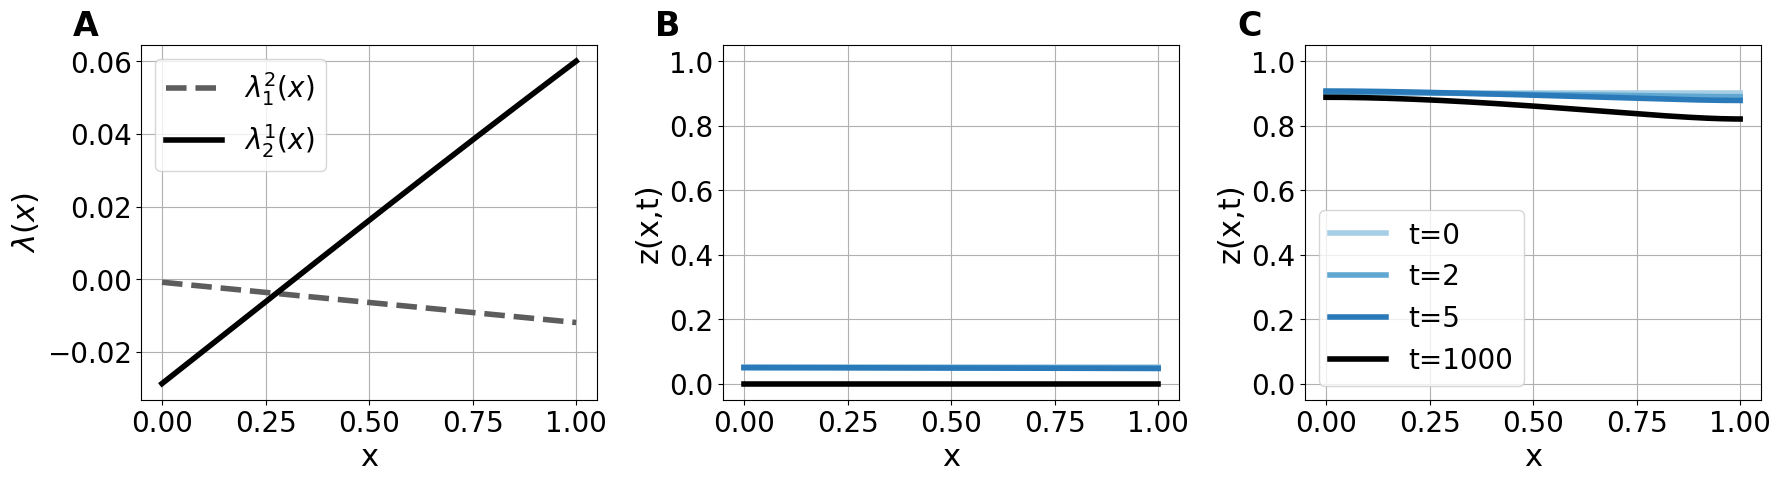

In [72]:
lambda12_base = lambda y: np.interp(y, x, Lambda[0, 1])
lambda21_example = lambda y: np.interp(y, x, Lambda[1, 0])
v_func = lambda y: np.interp(y, x, aux["vartheta"])

# lambda12_base = lambda x:  0.25 - 0.4*x
# lambda21_example = lambda x:  -0.15 + 0.2*x

D_func = lambda x: (1 + 0*x) * 1e-2
# v_func = lambda x: (0.1 +0*x)

example1, _ =  plot_lambda_functions(lambda12_base, lambda21_example)
plt.close(example1)

example2, _ = plot_sol_evolutiontheta(
    lambda12_base=lambda12_base,
    lambda21=lambda21_example,
    D_func=D_func,
    v_func=v_func,
    a= 1,
    L=1.0,
    Nx=200,
    T=1000,
    z0 = 0.05*np.ones(200),
    t_samples=[0, 2, 5, 1000],
    theta = Theta_sum
)
plt.close(example2)

example3, _ = plot_sol_evolutiontheta(
    lambda12_base=lambda12_base,
    lambda21=lambda21_example,
    D_func=D_func,
    v_func=v_func,
    a= 1,
    L=1.0,
    Nx=200,
    T=1000,
    z0 = 0.9*np.ones(200),
    t_samples=[0, 2, 5, 1000],
    legend=True,
    theta = Theta_sum
)


plt.close(example3)

fig = join_axes_side_by_side([example1, example2, example3],
                             labels=("A","B","C"),
                             panel_fontsize=24,
                             panel_dx=-0.15,
                             panel_dy=1.1)
#fig.savefig("2ndquadrantexamples_2.pdf", bbox_inches="tight")       # PDF

In [73]:
D_func=lambda x: (1 + 0. * x) * 1e-2

print(estimate_principal_eigenvalue_variable_D_advection(
    D_func, v_func, lambda12_base, N=1001))

print(estimate_principal_eigenvalue_variable_D_advection(
    D_func, v_func, lambda21_example, N=1001))

-0.004120790235996635
0.0005283065374461909


In [74]:
# ------------------------------------------------------------
# Extract strain-specific SIS parameters from params
# ------------------------------------------------------------
beta_1 = params["beta_i"][0]
beta_2 = params["beta_i"][1]

gamma_1 = params["gamma_i"][0]
gamma_2 = params["gamma_i"][1]

gamma_11 = params["gamma_ij"][0, 0]
gamma_22 = params["gamma_ij"][1, 1]
gamma_12 = params["gamma_ij"][0, 1]
gamma_21 = params["gamma_ij"][1, 0]

k_11 = params["k_ij"][0, 0]
k_22 = params["k_ij"][1, 1]
k_12 = params["k_ij"][0, 1]
k_21 = params["k_ij"][1, 0]

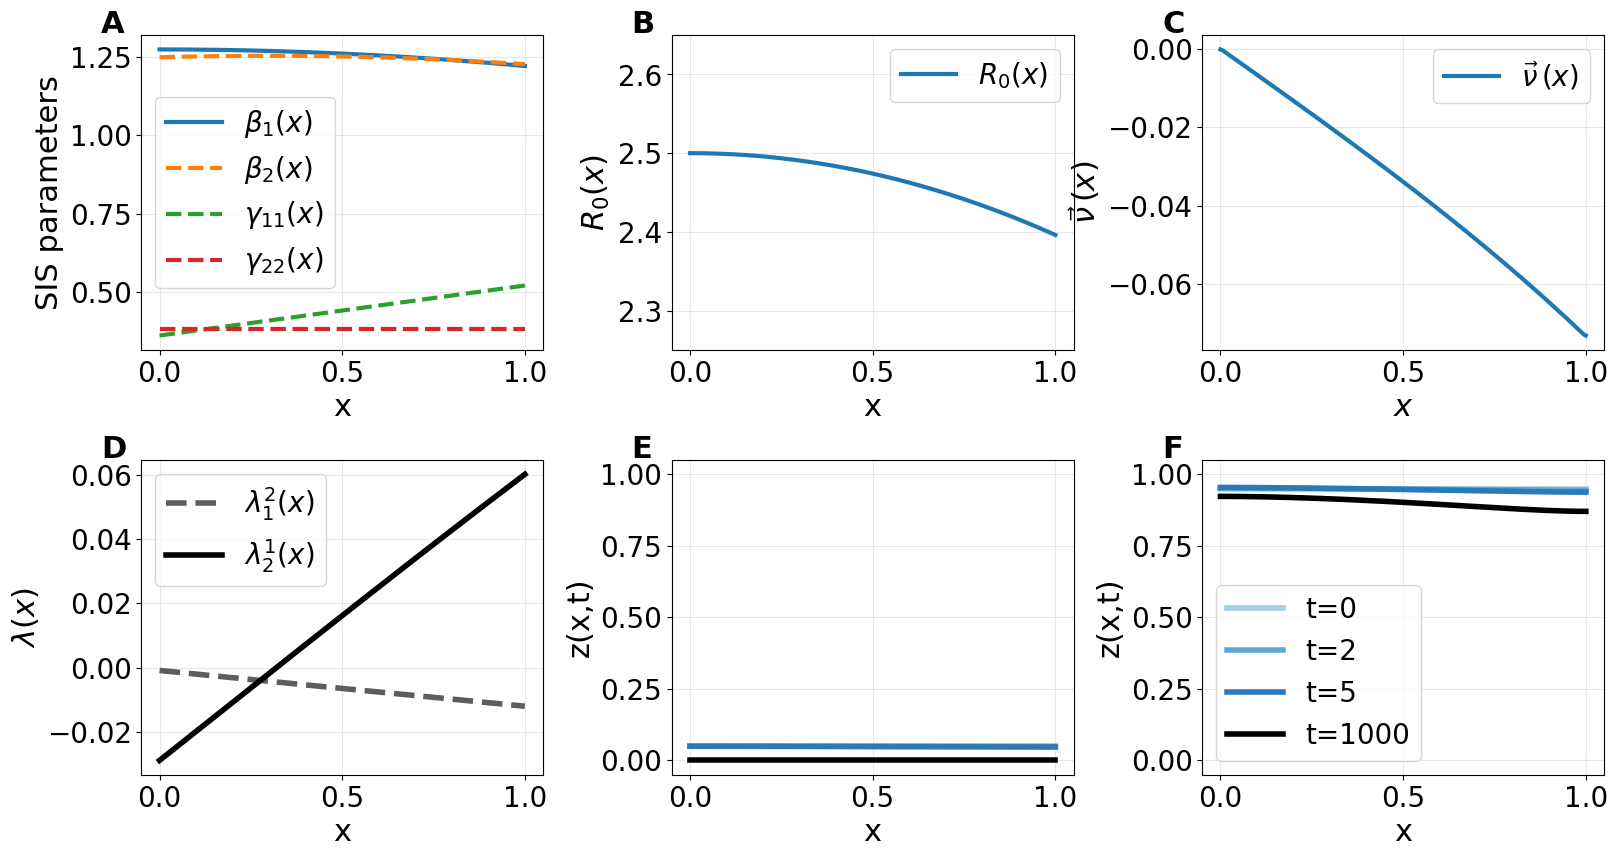

In [75]:
# ------------------------------------------------------------
# A. Varying SIS parameters
# ------------------------------------------------------------
fig_params, ax = plt.subplots(figsize=(5.5, 4.5))

ax.plot(x, beta_1, label=r"$\beta_1(x)$", linewidth=3)
ax.plot(x, beta_2, "--", label=r"$\beta_2(x)$", linewidth=3)

ax.plot(x, gamma_11, "--", label=r"$\gamma_{11}(x)$", linewidth=3)
ax.plot(x, gamma_22, "--", label=r"$\gamma_{22}(x)$", linewidth=3)

ax.set_xlabel("x")
ax.set_ylabel("SIS parameters")
ax.grid(True, alpha=0.3)
ax.legend()

# ------------------------------------------------------------
# B. R0
# ------------------------------------------------------------
fig_R0, ax = plt.subplots(figsize=(5.5, 4.5))

ax.plot(x, aux["R0"], linewidth=3, label=r"$R_0(x)$")

ax.set_xlabel("x")
ax.set_ylabel(r"$R_0(x)$")

ax.set_ylim(2.25, 2.65)
ax.set_yticks([2.3, 2.4, 2.5, 2.6])

ax.grid(True, alpha=0.3)
ax.legend()

# ------------------------------------------------------------
# C. Advection
# ------------------------------------------------------------
fig_adv, ax = plt.subplots(figsize=(5.5, 4.5))

ax.plot(
    x,
    aux["vartheta"],
    linewidth=3,
    label=r"$\vec{\nu}\,(x)$"
)

ax.set_xlabel(r"$x$")
ax.set_ylabel(r"$\vec{\nu}\,(x)$")
ax.grid(True, alpha=0.3)
ax.legend()

# ------------------------------------------------------------
# D. Lambdas
# ------------------------------------------------------------
fig_lambdas, ax =  plot_lambda_functions(lambda12_base, lambda21_example)
plt.close(fig_lambdas)

# ------------------------------------------------------------
# E. Low initial condition
# ------------------------------------------------------------
fig_low, ax_low = plot_sol_evolutiontheta(
    lambda12_base=lambda12_base,
    lambda21=lambda21_example,
    D_func=D_func,
    v_func=v_func,
    a=1,
    L=1.0,
    Nx=200,
    T=1000,
    z0=0.05*np.ones(200),
    t_samples=[0, 2, 5, 1000],
    legend=False,
    theta = Theta_sum
)


# ------------------------------------------------------------
# F. High initial condition
# ------------------------------------------------------------
fig_high, ax_high = plot_sol_evolutiontheta(
    lambda12_base=lambda12_base,
    lambda21=lambda21_example,
    D_func=D_func,
    v_func=v_func,
    a=1,
    L=1.0,
    Nx=200,
    T=1000,
    z0=0.95*np.ones(200),
    t_samples=[0, 2, 5, 1000],
    legend=True,
    theta = Theta_sum
)


final_fig, final_axes = join_axes_grid(
    [
        fig_params,
        fig_R0,
        fig_adv,
        fig_lambdas,
        fig_low,
        fig_high,
    ],
    labels=("A", "B", "C", "D", "E", "F"),
    nrows=2,
    ncols=3,
    width_per_panel=5.3,
    height_per_panel=4.3,
    panel_fontsize=22,
)

#final_fig.savefig("replicator_sis_example.pdf", bbox_inches="tight")

for fig in [fig_params, fig_R0, fig_adv, fig_lambdas, fig_low, fig_high]:
    plt.close(fig)

plt.show()

# Backward bifurcation figure

## Backward bifurcation code

In [27]:
def construct_neumann_laplacian(N, dx, D):
    main_diag = -2 * np.ones(N)
    off_diag = 1 * np.ones(N - 1)

    laplacian = np.diag(main_diag) + np.diag(off_diag, 1) + np.diag(off_diag, -1)

    # Neumann BCs
    laplacian[0, 0] = -1
    laplacian[-1, -1] = -1

    return (D / dx**2) * laplacian

def find_steady_state(
    L=1.0,
    Nx=100,
    D=0.01,
    lambda12=lambda x: 1,
    lambda21=lambda x: 0.5 - 2 * x,
    guess_range=(0.05, 1.0),
    guess_step=0.01,
    tol_solution=1e-3,
    tol_integral=1e-3
):
    x = np.linspace(0, L, Nx)
    dx = x[1] - x[0]

    laplacian = construct_neumann_laplacian(Nx, dx, D)

    def steady_state_system(z):
        lam12_vals = lambda12(x)
        lam21_vals = lambda21(x)
        reaction = z * (1 - z) * (lam12_vals - (lam12_vals + lam21_vals) * z)
        diffusion = laplacian.dot(z)
        return reaction + diffusion

    guess_values = np.arange(guess_range[0], guess_range[1] + guess_step, guess_step)

    for guess in guess_values:
        z0 = guess * np.ones(Nx)
        sol = root(steady_state_system, z0, method='hybr')

        if sol.success:
            z_steady = sol.x
            if np.all((z_steady >= -tol_solution) & (z_steady <= 1 + tol_solution)):
                integral_simps = simps(z_steady, x)
                if (np.abs(integral_simps) >= tol_integral) and (integral_simps <= 1 - tol_integral):
                    return z_steady, x, integral_simps
    return None, x, None

def compute_bifurcation_diagram(
    lambda12_base,
    lambda21,
    L=1.0,
    Nx=200,
    D=0.01,
    T=1000,
    tolerance=1e-4,
    a_values=np.linspace(-2, 2, 51),
    guess_range=(0.05, 1.0),
    guess_step=0.01
):
    x = np.linspace(0, L, Nx)
    dx = x[1] - x[0]

    lap = construct_neumann_laplacian(Nx, dx, D)

    z01 = 0.999 * np.ones(Nx)
    z02 = 0.001 * np.ones(Nx)

    mean_values1 = []
    mean_values2 = []
    solutions1 = []
    solutions2 = []
    unstable_solutions = []

    for a in a_values:
        lambda12 = lambda x: a * lambda12_base(x)

        def rhs(t, z):
            lam12 = lambda12(x)
            lam21_val = lambda21(x)
            reaction = z * (1 - z) * (lam12 - (lam12 + lam21_val) * z)
            diffusion = lap.dot(z)
            return reaction + diffusion

        # Solve with z01
        sol1 = solve_ivp(rhs, [0, T], z01, method='BDF', t_eval=[T])
        z_T1 = sol1.y[:, -1]
        mean_z1 = simps(z_T1, x) / (x[-1] - x[0])
        integral_z1 = simps(z_T1, x)
        mean_values1.append(mean_z1)
        if integral_z1 > tolerance:
            solutions1.append((a, z_T1.copy()))

        # Solve with z02
        sol2 = solve_ivp(rhs, [0, T], z02, method='BDF', t_eval=[T])
        z_T2 = sol2.y[:, -1]
        mean_z2 = simps(z_T2, x) / (x[-1] - x[0])
        integral_z2 = simps(z_T2, x)
        mean_values2.append(mean_z2)
        if integral_z2 > tolerance:
            solutions2.append((a, z_T2.copy()))

    # Unstable branch (steady-state solver)
    coexistence_a_values = [x[0] for x in solutions1 if x[0] < 0]
    coexistence_a_values.append(-0.001)  # to ensure overlap

    unstable_solutions_means = []
    for a in coexistence_a_values:
        unstable_z, x_vals, unstable_mean = find_steady_state(
            L=L,
            Nx=Nx,
            D=D,
            lambda12=lambda x: a * lambda12_base(x),
            lambda21=lambda21,
            guess_range=guess_range,
            guess_step=guess_step
        )
        unstable_solutions_means.append(unstable_mean)
        unstable_solutions.append((a, unstable_z))


    # Return results
    return {
        'a_values': a_values,
        'mean_values1': mean_values1,
        'mean_values2': mean_values2,
        'unstable_a_values': coexistence_a_values,
        'unstable_means': unstable_solutions_means,
        'x': x,
        'solutions1': solutions1,
        'solutions2': solutions2,
        'unstable_sols': unstable_solutions
    }

def plot_bifurcation_diagram(results, filename='bifurcation_plot.pdf', blue_y1_line=False):
    plt.figure(figsize=(8, 6))

    # Plot stable points
    plt.plot(results['a_values'], results['mean_values1'], 'b.', markersize=4, label='Stable')
    plt.plot(results['a_values'], results['mean_values2'], 'b.', markersize=4)

    # Plot horizontal line at y=0 (always red)
    plt.plot([0.01, 1.5], [0, 0], 'r-', linewidth=2.2)

    # Plot horizontal line at y=1
    y1_color = 'blue' if blue_y1_line else 'red'
    plt.plot([-1.5, 1.5], [1, 1], color=y1_color, linewidth=2.2)

    # Plot unstable branch
    plt.plot(results['unstable_a_values'], results['unstable_means'], 'r.-', markersize=4, linewidth=2.2, label='Unstable')

    plt.xlabel('a (bifurcation parameter)')
    plt.ylabel('Spatial mean of z(x, T)')
    plt.title('Bifurcation Diagram')
    plt.grid(True)
    plt.legend()
    plt.savefig(filename, format='pdf', bbox_inches='tight', dpi=1200)
    plt.show()

In [95]:
def make_bifurcation_figure2(
    results,
    blue_y1_line=False,
    figsize=(6, 5),
    target_a=-0.2,
    zero_tol=1e-2
):
    fig, ax = plt.subplots(figsize=figsize)

    # ======================================================
    # Extract data
    # ======================================================
    a_vals = np.asarray(results["a_values"], dtype=float)

    mv1 = np.asarray(results["mean_values1"], dtype=float).copy()
    mv2 = np.asarray(results["mean_values2"], dtype=float).copy()

    a_min = a_vals.min()
    a_max = a_vals.max()

    # ======================================================
    # Helper: break plotted curves at y=0
    # ======================================================
    def break_at_y0(y):
        y = np.asarray(y, dtype=float).copy()
        y[np.abs(y) < zero_tol] = np.nan
        return y

    mv1_plot = break_at_y0(mv1)
    mv2_plot = break_at_y0(mv2)

    # ======================================================
    # Stable branches: solid blue
    # ======================================================
    ax.plot(
        a_vals,
        mv1_plot,
        color="blue",
        linestyle="-",
        linewidth=2.2,
        label="Stable",
        zorder=2
    )

    ax.plot(
        a_vals,
        mv2_plot,
        color="blue",
        linestyle="-",
        linewidth=2.2,
        zorder=2
    )

    # ======================================================
    # Unstable branch: dashed red
    # ======================================================
    ua = None
    um = None

    if "unstable_a_values" in results and "unstable_means" in results:
        ua = np.asarray(results["unstable_a_values"], dtype=float)
        um = np.asarray(results["unstable_means"], dtype=float)

        um_plot = break_at_y0(um)

        ax.plot(
            ua,
            um_plot,
            color="red",
            linestyle="--",
            linewidth=2.2,
            label="Unstable",
            zorder=5
        )

    # ======================================================
    # Manually add black crosses closest to target_a
    # using mean_values1 and mean_values2
    # ======================================================
    idx = np.argmin(np.abs(a_vals - target_a))

    a_cross = a_vals[idx]
    y_cross_1 = mv1[idx]
    y_cross_2 = mv2[idx]

    print("Closest stable a:", a_cross)
    print("mean_values1 at closest a:", y_cross_1)
    print("mean_values2 at closest a:", y_cross_2)

    cross_label_used = False

    if np.isfinite(y_cross_1) and abs(y_cross_1) > zero_tol:
        ax.plot(
            a_cross,
            y_cross_1,
            marker="X",
            color="black",
            markersize=11,
            markeredgewidth=1,
            linestyle="None",
            zorder=300,
            label=rf"$a \approx {a_cross:.3g}$"
        )
        cross_label_used = True

    if np.isfinite(y_cross_2) and abs(y_cross_2) > zero_tol:
        ax.plot(
            a_cross,
            y_cross_2,
            marker="X",
            color="black",
            markersize=11,
            markeredgewidth=1,
            linestyle="None",
            zorder=300,
            label=None if cross_label_used else rf"$a \approx {a_cross:.3g}$"
        )
        cross_label_used = True

    # ======================================================
    # Manually add black cross closest to target_a
    # using unstable_a_values and unstable_means
    # ======================================================
    if ua is not None and um is not None:
        valid_red = (
            np.isfinite(ua)
            & np.isfinite(um)
            & (np.abs(um) > zero_tol)
        )

        if np.any(valid_red):
            idx_valid = np.where(valid_red)[0]
            idx_red = idx_valid[np.argmin(np.abs(ua[idx_valid] - target_a))]

            a_cross_red = ua[idx_red]
            y_cross_red = um[idx_red]

            print("Closest unstable a:", a_cross_red)
            print("unstable mean at closest a:", y_cross_red)

            ax.plot(
                a_cross_red,
                y_cross_red,
                marker="X",
                color="black",
                markersize=11,
                markeredgewidth=1,
                linestyle="None",
                zorder=300,
                label=None if cross_label_used else rf"$a \approx {a_cross_red:.3g}$"
            )
            cross_label_used = True

    # ======================================================
    # y=0 line split at a=0
    # ======================================================
    ax.plot(
        [a_min, 0],
        [0, 0],
        color="blue",
        linewidth=2.6,
        zorder=100,
        solid_capstyle="butt"
    )

    ax.plot(
        [0, a_max],
        [0, 0],
        color="red",
        linestyle="--",
        linewidth=2.6,
        zorder=100,
        solid_capstyle="butt"
    )

    # ======================================================
    # y=1 line
    # ======================================================
    y1_color = "blue" if blue_y1_line else "red"
    y1_style = "-" if blue_y1_line else "--"

    ax.plot(
        [a_min, a_max],
        [1, 1],
        color=y1_color,
        linestyle=y1_style,
        linewidth=2.2,
        zorder=50,
        solid_capstyle="butt"
    )

    # ======================================================
    # Formatting
    # ======================================================
    ax.set_xlim(a_min, a_max)
    ax.set_xticks([-1.5, -1.0, -0.5, 0.0, 0.5, 1.0, 1.5])

    ax.set_xlabel(r"$a$ (bifurcation parameter)")
    ax.set_ylabel(r"Spatial mean of $z(x,T)$")
    ax.set_title("Bifurcation diagram")

    ax.grid(True, alpha=0.3, zorder=0)
    ax.legend()

    return fig

Closest stable a: -0.19633333333333347
mean_values1 at closest a: 0.7913060572099443
mean_values2 at closest a: -1.2327319112850433e-11
Closest unstable a: -0.19633333333333347
unstable mean at closest a: 0.09231666180312394


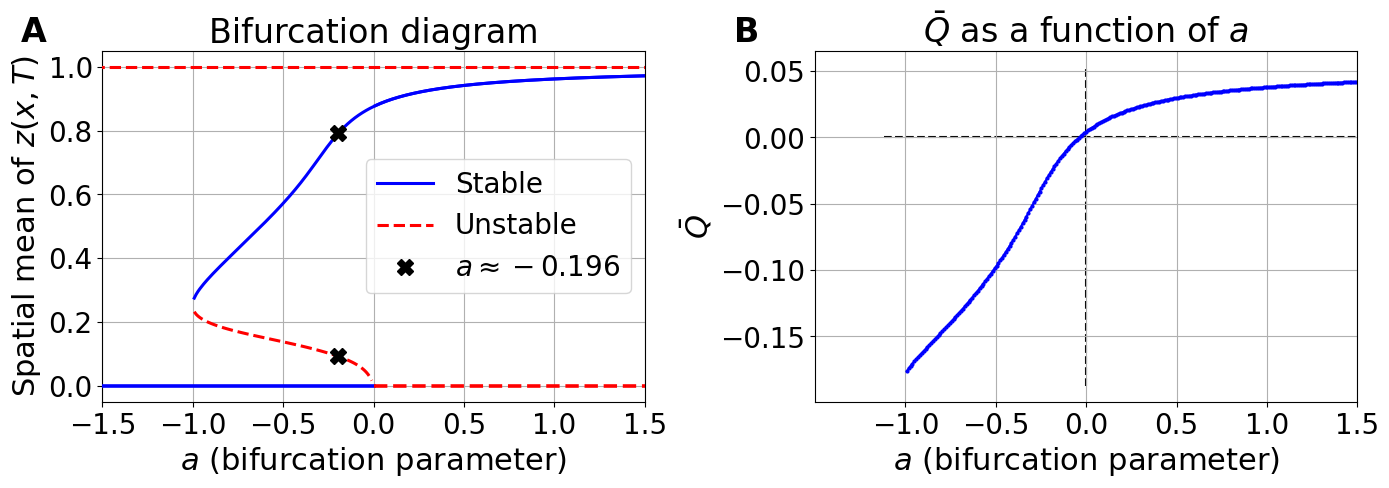

In [96]:
fig_bif = make_bifurcation_figure2(results, blue_y1_line=False, figsize=(7, 5))
plt.close(fig_bif)

fig_Q = make_meanQ_figure(
    results,
    lambda12_base=lambda12_base,
    lambda21=lambda21,
    L=1.0,
    Nx=200,
    branch='solutions1',  # or 'solutions2'
    normalize=True,
    figsize=(7, 5)
)
plt.close(fig_Q)

# --- Combine using YOUR existing join function
fig_combined = join_axes_side_by_side(
    [fig_bif, fig_Q],
    labels=("A", "B"),
    # if your join has autosizing, use your standard:
    width_per_panel=7, height=5,
    panel_fontsize=24,
    panel_dx=-0.15,
    panel_dy=1.10
)

ax0 = fig_combined.axes[0]
ax0.set_xticks(np.arange(-1.5, 1.5 + 0.5, 0.5))
ax0.set_xlim(-1.5, 1.5)

ax1 = fig_combined.axes[1]
ax1.set_xticks(np.arange(-1, 1.5 + 0.5, 0.5))
ax1.set_xlim(-1.5, 1.5)


# --- Save
fig_combined.savefig("bifurcation_and_meanQ.pdf", bbox_inches="tight")

## Plotting stable and unstable solutions

In [97]:
def get_solution_figure_at_a(results, a_target, solution_type='solutions1'):
    """
    Return a matplotlib figure of the spatial solution z(x) at a given a_target.

    solution_type:
        'solutions1'   -> stable branch
        'solutions2'   -> second stable branch (if present)
        'unstable_sols' -> unstable branch
    """
    import numpy as np
    import matplotlib.pyplot as plt

    if solution_type not in ['solutions1', 'solutions2', 'unstable_sols']:
        raise ValueError("solution_type must be 'solutions1', 'solutions2', or 'unstable_sols'")

    x = results['x']
    sol_list = results[solution_type]

    # --- remove None solutions (important for unstable branch)
    sol_list = [(a, z) for (a, z) in sol_list if z is not None]

    if len(sol_list) == 0:
        raise ValueError(f"No valid solutions in {solution_type}")

    # --- find closest a (more robust than exact match)
    a_vals = np.array([a for a, _ in sol_list])
    idx = np.argmin(np.abs(a_vals - a_target))
    a_found, sol = sol_list[idx]

    # --- labels (keep your titles)
    if solution_type == 'unstable_sols':
        title = "Unstable solution"
    else:
        title = "Stable solution"

    # --- plotting
    fig, ax = plt.subplots(figsize=(6, 5))

    ax.plot(x, sol, linewidth=4, label=rf"$a = {a_found:.3f}$")
    ax.legend()
    ax.set_xlabel("x")
    ax.set_ylabel("z(x)")
    ax.set_title(title)
    ax.grid(True, alpha=0.3)
    ax.set_ylim(-0.05, 1.05)

    # show actual a used (important when closest match)
    #ax.legend([f"a = {a_found:.3f}"])

    return fig

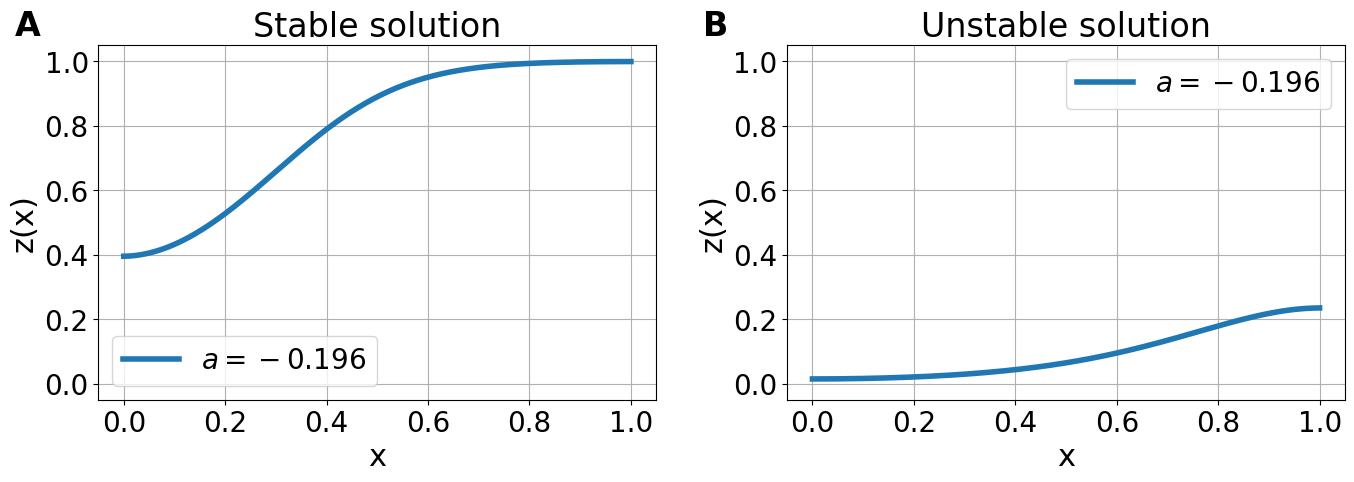

In [98]:
fig_stable = get_solution_figure_at_a(results, -0.2, 'solutions1')
fig_unstable = get_solution_figure_at_a(results, -0.2, 'unstable_sols')

plt.close(fig_stable)
plt.close(fig_unstable)

fig_combined = join_axes_side_by_side(
    [fig_stable, fig_unstable],
    labels=("A", "B"),
    # if your join has autosizing, use your standard:
    width_per_panel=7, height=5,
    panel_fontsize=24,
    panel_dx=-0.15,
    panel_dy=1.10
)



# --- Save
#fig_combined.savefig("unstable_sols_example.pdf", bbox_inches="tight")

## Plotting Q at previous point

In [99]:
def get_Q_figure_at_a(results, a_target, lambda12_base, lambda21,
                      solution_type='solutions1'):
    """
    Return a matplotlib figure of

        Q(x) = (lambda_1^2(x) + lambda_2^1(x)) z(x)(1-z(x))

    where lambda_1^2(x) = a * lambda12_base(x),
    using the stored solution closest to a_target.
    """
    import numpy as np
    import matplotlib.pyplot as plt

    if solution_type not in ['solutions1', 'solutions2', 'unstable_sols']:
        raise ValueError("solution_type must be 'solutions1', 'solutions2', or 'unstable_sols'")

    x = results['x']
    sol_list = results[solution_type]

    # remove invalid entries
    sol_list = [(a, z) for (a, z) in sol_list if z is not None]
    if len(sol_list) == 0:
        raise ValueError(f"No valid solutions in {solution_type}")

    # closest parameter value
    a_vals = np.array([a for a, _ in sol_list])
    idx = np.argmin(np.abs(a_vals - a_target))
    a_found, z = sol_list[idx]

    # consistent with make_meanQ_figure
    lambda12_vals = a_found * lambda12_base(x)
    lambda21_vals = lambda21(x)

    Q = (lambda12_vals + lambda21_vals) * z * (1 - z)

    title = "Q(x) for unstable solution" if solution_type == 'unstable_sols' else "Q(x) for stable solution"

    fig, ax = plt.subplots(figsize=(6, 5))
    ax.plot(x, Q, linewidth=4, label=rf"$a = {a_found:.3f}$")
    ax.axhline(0, color='black', linewidth=1, alpha=0.6)
    ax.set_xlabel("x")
    ax.set_ylabel("Q(x)")
    ax.set_title(title)
    ax.grid(True, alpha=0.3)
    ax.legend()

    return fig

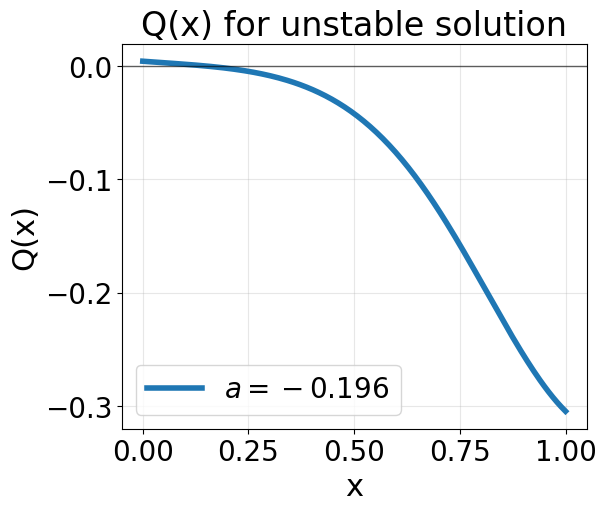

In [100]:
figD1 = get_Q_figure_at_a(
    results,
    a_target=-0.2,
    lambda12_base=lambda12_base,
    lambda21=lambda21,
    solution_type='unstable_sols')
plt.show()

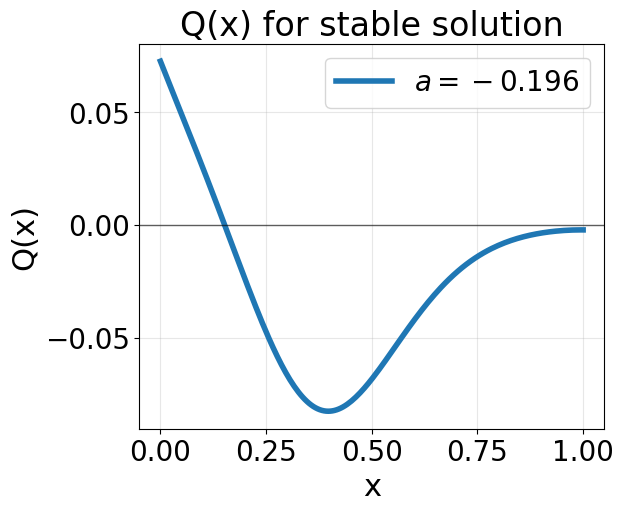

In [101]:
figD2 = get_Q_figure_at_a(
    results,
    a_target=-0.2,
    lambda12_base=lambda12_base,
    lambda21=lambda21,
    solution_type='solutions1'
)
plt.show()

In [102]:
#Combining all
import matplotlib.pyplot as plt

def join_axes_2cols_3rows(
    figs,
    labels=("A", "B", "C", "D"),
    figsize=(12, 13),
    keep_limits=True,
    keep_labels=True,
    panel_fontsize=24,
    panel_dx=-0.12,
    panel_dy=1.12,
    wspace=0.3,
    hspace=0.4,
):
    """
    Join 6 figures into a 3x2 layout:

        A   B
        C   D
        E   F

    but only label the first four panels by default.

    Expected order:
        [A, B, C, D, E, F]
    """

    if len(figs) != 6:
        raise ValueError("figs must contain exactly 6 figures")

    out_fig, out_axes = plt.subplots(3, 2, figsize=figsize, squeeze=False)
    out_axes = out_axes.flatten()

    def copy_ax_contents(src_ax, dst_ax, panel_label=None):
        # ---- Copy lines
        for line in src_ax.get_lines():
            dst_ax.plot(
                line.get_xdata(), line.get_ydata(),
                linestyle=line.get_linestyle(),
                linewidth=line.get_linewidth(),
                marker=line.get_marker(),
                markersize=line.get_markersize(),
                color=line.get_color(),
                alpha=line.get_alpha(),
                zorder=line.get_zorder(),
                label=line.get_label()
            )

        # ---- Copy labels/titles
        if keep_labels:
            dst_ax.set_title(src_ax.get_title())
            dst_ax.set_xlabel(src_ax.get_xlabel())
            dst_ax.set_ylabel(src_ax.get_ylabel())

        # ---- Copy limits
        if keep_limits:
            dst_ax.set_xlim(src_ax.get_xlim())
            dst_ax.set_ylim(src_ax.get_ylim())

        # ---- Copy grid visibility
        grid_visible = (
            any(gl.get_visible() for gl in src_ax.get_xgridlines()) or
            any(gl.get_visible() for gl in src_ax.get_ygridlines())
        )
        if grid_visible:
            dst_ax.grid(True)

        # ---- Copy legend if present
        handles, labels_ = src_ax.get_legend_handles_labels()
        if handles:
            dst_ax.legend(handles, labels_)

        # ---- Panel label
        if panel_label is not None:
            dst_ax.text(
                panel_dx, panel_dy, panel_label,
                transform=dst_ax.transAxes,
                fontsize=panel_fontsize,
                fontweight="bold",
                va="top",
                ha="left",
                clip_on=False
            )

    for i, (src_fig, dst_ax) in enumerate(zip(figs, out_axes)):
        src_ax = src_fig.axes[0]
        panel_label = labels[i] if i < len(labels) else None
        copy_ax_contents(src_ax, dst_ax, panel_label=panel_label)

    out_fig.subplots_adjust(
        left=0.10,
        right=0.98,
        top=0.96,
        bottom=0.07,
        wspace=wspace,
        hspace=hspace
    )

    return out_fig

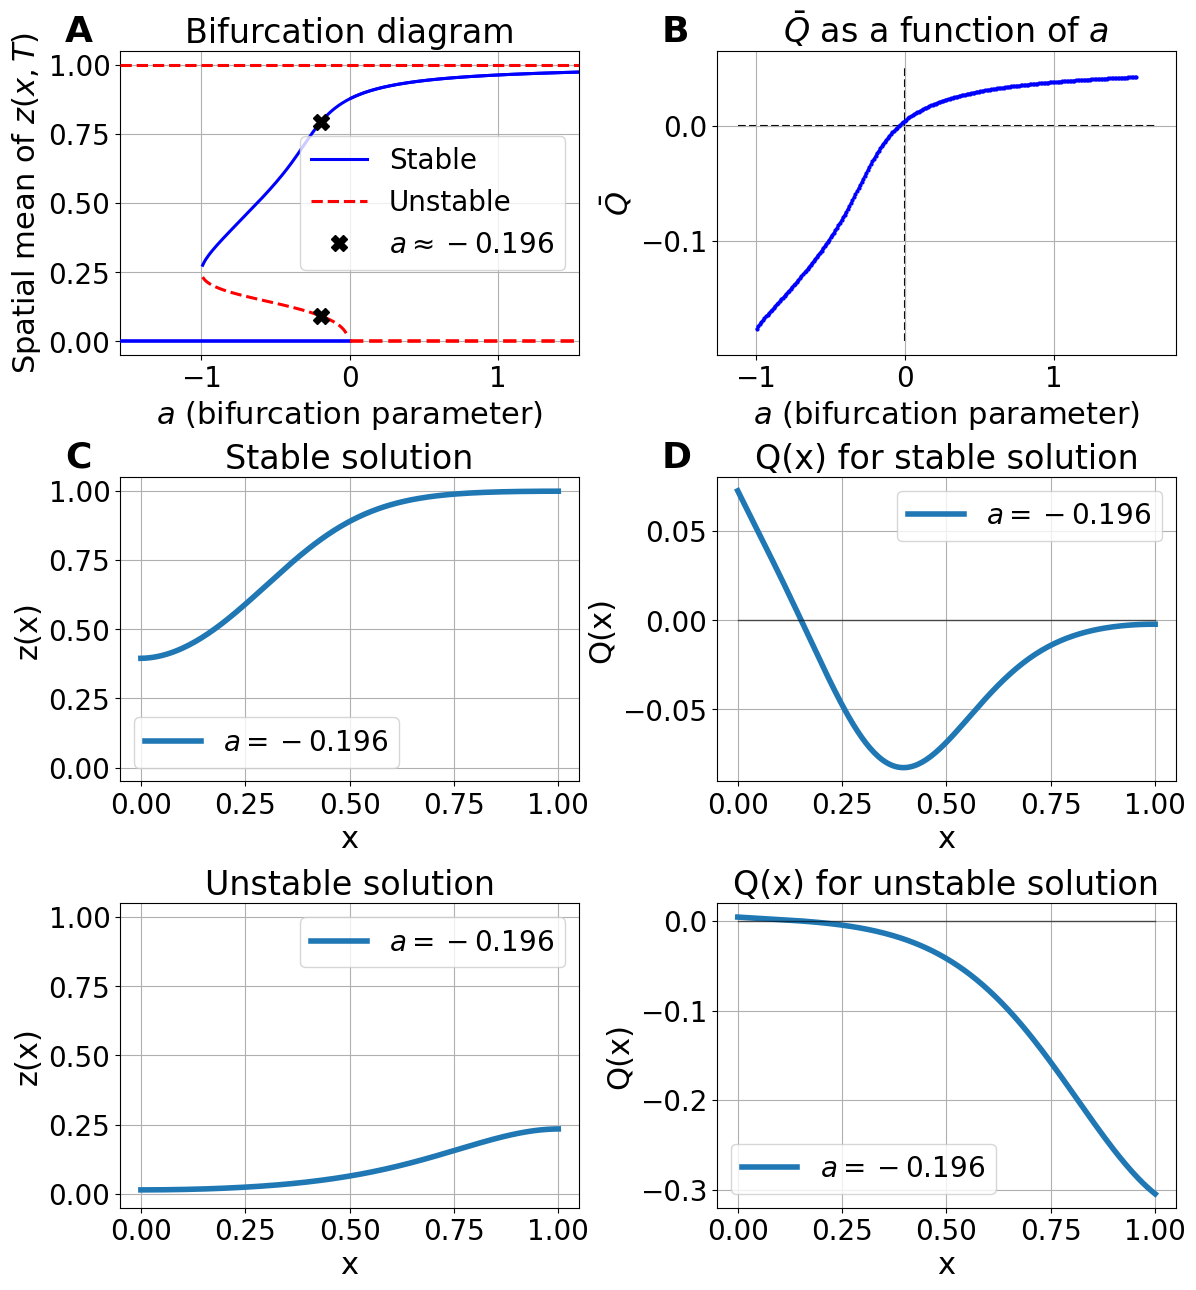

In [133]:
joined_fig = join_axes_2cols_3rows(
    [fig_bif, fig_Q, fig_stable, figD2, fig_unstable, figD1],
    labels=("A", "B", "C", "D"),
    figsize=(12, 13),
    panel_fontsize=26
)
plt.show()
#joined_fig.savefig("bifurcation_diagram_panel.pdf", bbox_inches="tight")

# Showing how diffusion affects the bifurcation branch

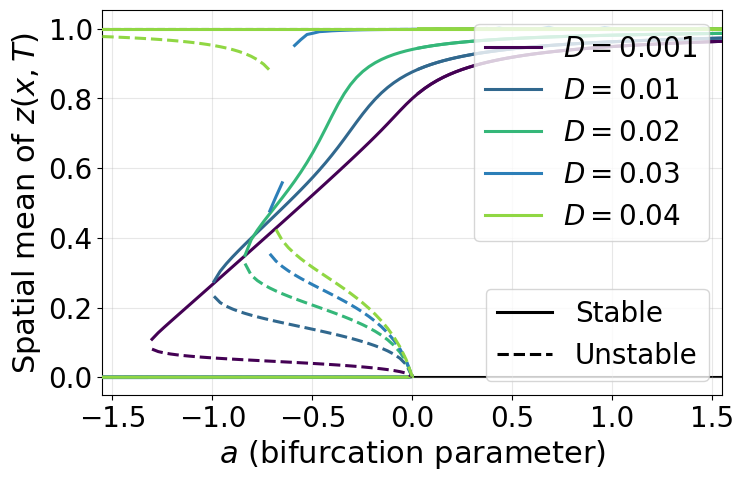

In [120]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D


def plot_branch_with_breaks(ax, x, y, jump_thresh=0.08, **kwargs):

    
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    mask = np.isfinite(x) & np.isfinite(y)
    x = x[mask]
    y = y[mask]

    if len(x) < 2:
        return

    jumps = np.where(np.abs(np.diff(y)) > jump_thresh)[0]

    starts = np.r_[0, jumps + 1]
    ends = np.r_[jumps + 1, len(x)]

    for s, e in zip(starts, ends):
        if e - s >= 2:
            ax.plot(x[s:e], y[s:e], **kwargs)


def overlay_bifurcations_varying_D(
    D_values,
    lambda12_base,
    lambda21,
    blue_y1_line=False,   # kept only so your calls don't break
    figsize=(8, 5),
    cmap_name="viridis",
    jump_thresh=0.08,
    a_values=None,
):

    

    if a_values is None:
        a_values = np.linspace(-1.55, 1.55, 101)

    D_values = list(D_values)
    nD = len(D_values)

    fig, ax = plt.subplots(figsize=figsize)

    # one color per D
    #cmap = plt.get_cmap("cividis", nD)
    #colors = [cmap(i) for i in range(nD)]
    colors = ["#440154", "#31688e", "#35b779", "#2c7fb8", "#90d743"]

    first_results = None

    for i, D in enumerate(D_values):
        results = compute_bifurcation_diagram(
            lambda12_base=lambda12_base,
            lambda21=lambda21,
            D=D,
            a_values=a_values
        )

        if first_results is None:
            first_results = results

        color = colors[i]

        # Stable branches
        a_stable = np.asarray(results["a_values"], dtype=float)
        y1 = np.asarray(results["mean_values1"], dtype=float)
        y2 = np.asarray(results["mean_values2"], dtype=float)

        plot_branch_with_breaks(
            ax,
            a_stable,
            y1,
            jump_thresh=jump_thresh,
            color=color,
            linestyle="-",
            linewidth=2.2,
            zorder=3,
        )

        plot_branch_with_breaks(
            ax,
            a_stable,
            y2,
            jump_thresh=jump_thresh,
            color=color,
            linestyle="-",
            linewidth=2.2,
            zorder=3,
        )

        # Unstable branch
        if "unstable_a_values" in results and "unstable_means" in results:
            ua = np.asarray(results["unstable_a_values"], dtype=float)
            um = np.asarray(results["unstable_means"], dtype=float)

            plot_branch_with_breaks(
                ax,
                ua,
                um,
                jump_thresh=jump_thresh,
                color=color,
                linestyle="--",
                linewidth=2.2,
                zorder=5,
            )

    # Reference lines in black
    a_min = np.min(first_results["a_values"])
    a_max = np.max(first_results["a_values"])

    # z = 0 branch
    ax.plot([a_min, 0], [0, 0], color="black", linewidth=1.5, linestyle="--", zorder=1)
    ax.plot([0, a_max], [0, 0], color="black", linewidth=1.5, linestyle="-", zorder=1)

    # z = 1 branch
    ax.plot([a_min, a_max], [1, 1], color="black", linewidth=1.5, linestyle="--", zorder=1)

    ax.set_xlim(a_min, a_max)
    ax.set_xticks([-1.5, -1.0, -0.5, 0.0, 0.5, 1.0, 1.5])
    ax.set_xlabel(r"$a$ (bifurcation parameter)")
    ax.set_ylabel(r"Spatial mean of $z(x,T)$")
    #ax.set_title("Effects of diffusion")
    ax.grid(True, alpha=0.3, zorder=0)

    # Legend for stability
    stability_handles = [
        Line2D([0], [0], color="black", lw=2.2, linestyle="-", label="Stable"),
        Line2D([0], [0], color="black", lw=2.2, linestyle="--", label="Unstable"),
    ]
    leg1 = ax.legend(handles=stability_handles, loc="lower right", frameon=True)
    ax.add_artist(leg1)

    # Legend for D values
    D_handles = [
        Line2D([0], [0], color=colors[i], lw=2.2, linestyle="-", label=fr"$D={D_values[i]:.3g}$")
        for i in range(nD)
    ]
    ax.legend(handles=D_handles, loc="upper right", frameon=True)

    return fig, ax
    
    
D_values = [1e-3, 1e-2, 2e-2, 3.0001e-2, 4e-2]

fig, ax = overlay_bifurcations_varying_D(
    D_values,
    lambda12_base,
    lambda21,
    
)

plt.show()

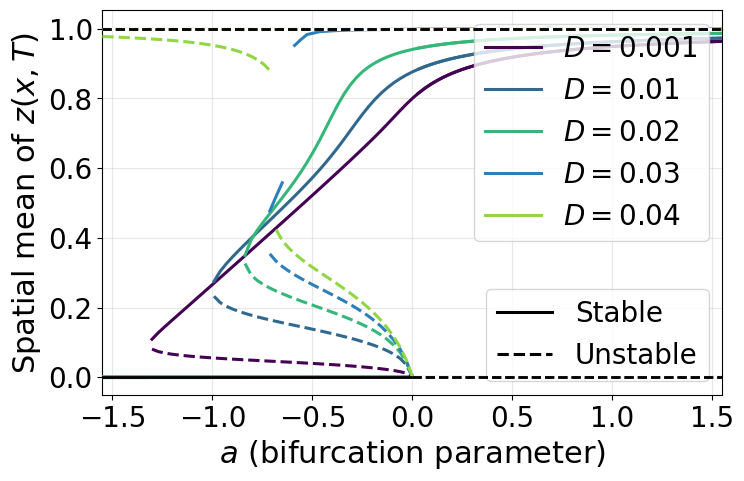

In [123]:
# Get current limits from the existing figure
a_min, a_max = ax.get_xlim()

# Hide whatever is currently at y=1
ax.plot(
    [a_min, a_max],
    [1, 1],
    color="white",
    linewidth=2.2,
    zorder=1000,
    solid_capstyle="butt"
)

# Draw black dashed line on top
ax.plot(
    [a_min, a_max],
    [1, 1],
    color="black",
    linestyle="--",
    linewidth=1.8,
    zorder=1001,
    solid_capstyle="butt"
)

# ------------------------------------------------------
# Cover and redraw z = 0 branch
# solid from -2 to 0, dashed from 0 to 3
# ------------------------------------------------------

# Hide whatever is currently at z=0
ax.plot(
    [-2, 3],
    [0, 0],
    color="white",
    linewidth=2.2,
    zorder=1000,
    solid_capstyle="butt"
)

# Solid black segment from -2 to 0
ax.plot(
    [-2, 0],
    [0, 0],
    color="black",
    linestyle="-",
    linewidth=1.8,
    zorder=1001,
    solid_capstyle="butt"
)

# Dashed black segment from 0 to 3
ax.plot(
    [0, 3],
    [0, 0],
    color="black",
    linestyle="--",
    linewidth=1.8,
    zorder=1001,
    solid_capstyle="butt"
)

plt.show()


# Keep the same x limits
ax.set_xlim(a_min, a_max)

fig

In [124]:
#fig.savefig("effectsofdiffusion_2.pdf", bbox_inches="tight")

# With advection now

In [128]:
def construct_advection_operator(N, dx, v):

    
    A = np.zeros((N, N))
    for i in range(1, N - 1):
        A[i, i - 1] = - v[i] / (2 * dx)
        A[i, i + 1] = + v[i] / (2 * dx)
    return A

    
def construct_neumann_laplacian_variable_D(N, dx, D):

    
    A = np.zeros((N, N))

    for i in range(1, N - 1):
        D_iphalf = 0.5 * (D[i] + D[i + 1])
        D_iminushalf = 0.5 * (D[i] + D[i - 1])

        A[i, i - 1] = D_iminushalf / dx**2
        A[i, i] = - (D_iphalf + D_iminushalf) / dx**2
        A[i, i + 1] = D_iphalf / dx**2

    # Neumann BC at left boundary (i = 0)
    D_phalf = 0.5 * (D[0] + D[1])
    A[0, 0] = -D_phalf / dx**2
    A[0, 1] = D_phalf / dx**2

    # Neumann BC at right boundary (i = N - 1)
    D_mhalf = 0.5 * (D[N - 1] + D[N - 2])
    A[N - 1, N - 2] = D_mhalf / dx**2
    A[N - 1, N - 1] = -D_mhalf / dx**2

    return A
    
x = np.linspace(0, 1, 100)

def find_steady_state(
    L=1.0,
    Nx=100,
    D=(1 + 0 * x) * 1e-2,
    lambda12=lambda x: 1,
    lambda21=lambda x: 0.5 - 2 * x,
    guess_range=(0.05, 1.0),
    guess_step=0.01,
    tol_solution=1e-3,
    tol_integral=1e-3,
    v=lambda x: 0 * 0.005 * x
):
    x = np.linspace(0, L, Nx)
    dx = x[1] - x[0]

    lap = construct_neumann_laplacian_variable_D(Nx, dx, D)
    adv = construct_advection_operator(Nx, dx, v)

    def steady_state_system(z):
        lam12_vals = lambda12(x)
        lam21_vals = lambda21(x)
        reaction = z * (1 - z) * (lam12_vals - (lam12_vals + lam21_vals) * z)
        diffusion = lap.dot(z)
        advection = adv.dot(z)
        return reaction + diffusion + advection

    guess_values = np.arange(guess_range[0], guess_range[1] + guess_step, guess_step)

    for guess in guess_values:
        z0 = guess * np.ones(Nx)
        sol = root(steady_state_system, z0, method='hybr')

        if sol.success:
            z_steady = sol.x
            if np.all((z_steady >= -tol_solution) & (z_steady <= 1 + tol_solution)):
                integral_simps = simps(z_steady, x)
                if (np.abs(integral_simps) >= tol_integral) and (integral_simps <= 1 - tol_integral):
                    return z_steady, x, integral_simps
    return None, x, None

def compute_bifurcation_diagram(
    lambda12_base,
    lambda21,
    L=1.0,
    Nx=200,
    D_func=0.01,
    T=1000,
    tolerance=1e-4,
    a_values=np.linspace(-2, 2, 51),
    guess_range=(0.05, 1.0),
    guess_step=0.01,
    v_func=lambda x: 0 * 0.005 * x,
    title=False
):

    x = np.linspace(0, L, Nx)
    dx = x[1] - x[0]
    
    D = D_func(x)
    v = v_func(x)
    g = g_func(x)

    lap = construct_neumann_laplacian_variable_D(Nx, dx, D)
    adv = construct_advection_operator(Nx, dx, v)
    
    z01 = 0.999 * np.ones(Nx)
    z02 = 0.001 * np.ones(Nx)

    mean_values1 = []
    mean_values2 = []
    solutions1 = []
    solutions2 = []

    for a in a_values:
        lambda12 = lambda x: a * lambda12_base(x)

        def rhs(t, z):
            lam12 = lambda12(x)
            lam21_val = lambda21(x)
            reaction = z * (1 - z) * (lam12 - (lam12 + lam21_val) * z)
            diffusion = lap.dot(z)
            advection = adv.dot(z)
            return reaction + diffusion + advection

        # Solve with z01
        sol1 = solve_ivp(rhs, [0, T], z01, method='BDF', t_eval=[T])
        try:
            z_T1 = sol1.y[:, -1]
        except Exception:
            print(f"ODE solver failed at a={a}")
            results.append((a, np.nan, np.nan))
            continue

        #z_T1 = sol1.y[:, -1]

        #z_T1 = np.asarray(sol1.y)[:, -1]
        mean_z1 = simps(z_T1, x) / (x[-1] - x[0])
        integral_z1 = simps(z_T1, x)
        mean_values1.append(mean_z1)
        if integral_z1 > tolerance:
            solutions1.append((a, z_T1.copy()))

        # Solve with z02
        sol2 = solve_ivp(rhs, [0, T], z02, method='BDF', t_eval=[T])
        z_T2 = sol2.y[:, -1]

        mean_z2 = simps(z_T2, x) / (x[-1] - x[0])
        integral_z2 = simps(z_T2, x)
        mean_values2.append(mean_z2)
        if integral_z2 > tolerance:
            solutions2.append((a, z_T2.copy()))

    # Unstable branch (steady-state solver)
    coexistence_a_values = [x[0] for x in solutions1 if x[0] < 0]

    unstable_solutions_means = []
    for a in coexistence_a_values:
        unstable_z, x_vals, unstable_mean = find_steady_state(
            L=L,
            Nx=Nx,
            D=D,
            lambda12=lambda x: a * lambda12_base(x),
            lambda21=lambda21,
            guess_range=guess_range,
            guess_step=guess_step,
            tol_solution=1e-3,
            tol_integral=1e-3,
            v=v
            
        )
        unstable_solutions_means.append(unstable_mean)

    # Return results
    return {
        'a_values': a_values,
        'mean_values1': mean_values1,
        'mean_values2': mean_values2,
        'unstable_a_values': coexistence_a_values,
        'unstable_means': unstable_solutions_means,
        'x': x,
        'solutions1': solutions1,
        'solutions2': solutions2
    }

def plot_bifurcation_diagram(
    results,
    filename='bifurcation_plot.pdf',
    blue_y1_line=False,
    title=False,
    xlim=(-2, 2),          # optional: keep your old limits but make them configurable
    y0_from_x0=True        # optional: toggle the new y=0 half-line
):
    fig, ax = plt.subplots(figsize=(8, 6))

    # --- determine x-range (use data if you want) ---
    xmin, xmax = xlim

    # --- horizontal lines (draw them "behind") ---
    # y = 1 line
    y1_color = 'blue' if blue_y1_line else 'red'
    ax.hlines(1, xmin=xmin, xmax=xmax, colors=y1_color, linewidth=2.2, zorder=1)

    # y = 0 line from x=0 to the right
    if y0_from_x0:
        ax.hlines(0, xmin=0, xmax=xmax, colors='red', linewidth=2.2, zorder=1)

    # --- branches ---
    # Unstable branch (red) (keep below blue dots if you want)
    ax.plot(
        results['unstable_a_values'], results['unstable_means'],
        'r.-', markersize=4, linewidth=2.2, label='Unstable', zorder=2
    )

    # Stable points (blue) on top
    ax.plot(
        results['a_values'], results['mean_values1'],
        'b.', markersize=4, label='Stable', zorder=5
    )
    ax.plot(
        results['a_values'], results['mean_values2'],
        'b.', markersize=4, zorder=5
    )

    ax.set_xlim(xmin, xmax)
    ax.set_xlabel('a (bifurcation parameter)')
    ax.set_ylabel('Spatial mean of z(x, T)')
    if title is True:
        ax.set_title('Effects of advection')
    ax.grid(True)
    ax.legend()

    fig.savefig(filename, format='pdf', bbox_inches='tight', dpi=1200)
    return fig

In [129]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from scipy.integrate import solve_ivp, simps
from scipy.optimize import root

def mask_boundary_values(y, eps=2e-2):

    y = np.asarray(y, dtype=float).copy()
    y[(y <= eps)] = np.nan
    return y

# ============================================================
# Low-level operators
# ============================================================

def construct_advection_operator(N, dx, v):

    A = np.zeros((N, N))
    for i in range(1, N - 1):
        A[i, i - 1] = -v[i] / (2 * dx)
        A[i, i + 1] = +v[i] / (2 * dx)
    return A


def construct_neumann_laplacian_variable_D(N, dx, D):

    A = np.zeros((N, N))

    for i in range(1, N - 1):
        D_iphalf = 0.5 * (D[i] + D[i + 1])
        D_iminushalf = 0.5 * (D[i] + D[i - 1])

        A[i, i - 1] = D_iminushalf / dx**2
        A[i, i]     = -(D_iphalf + D_iminushalf) / dx**2
        A[i, i + 1] = D_iphalf / dx**2

    # Left boundary
    D_phalf = 0.5 * (D[0] + D[1])
    A[0, 0] = -D_phalf / dx**2
    A[0, 1] =  D_phalf / dx**2

    # Right boundary
    D_mhalf = 0.5 * (D[-1] + D[-2])
    A[-1, -2] =  D_mhalf / dx**2
    A[-1, -1] = -D_mhalf / dx**2

    return A


# ============================================================
# Utility to avoid artificial vertical connectors
# ============================================================

def plot_branch_with_breaks(ax, x, y, jump_thresh=0.08, **kwargs):

    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    mask = np.isfinite(x) & np.isfinite(y)
    x = x[mask]
    y = y[mask]

    if len(x) < 2:
        return

    jumps = np.where(np.abs(np.diff(y)) > jump_thresh)[0]
    starts = np.r_[0, jumps + 1]
    ends   = np.r_[jumps + 1, len(x)]

    for s, e in zip(starts, ends):
        if e - s >= 2:
            ax.plot(x[s:e], y[s:e], **kwargs)


# ============================================================
# Steady-state solver for the unstable branch
# ============================================================

def find_steady_state(
    L=1.0,
    Nx=100,
    D=None,                          # array of length Nx
    lambda12=lambda x: 1.0 + 0*x,
    lambda21=lambda x: 0.5 - 2*x,
    guess_range=(0.05, 1.0),
    guess_step=0.01,
    tol_solution=1e-3,
    tol_integral=1e-3,
    v=None                           # array of length Nx
):
    x = np.linspace(0, L, Nx)
    dx = x[1] - x[0]

    if D is None:
        D = 1e-2 * np.ones(Nx)
    if v is None:
        v = np.zeros(Nx)

    lap = construct_neumann_laplacian_variable_D(Nx, dx, D)
    adv = construct_advection_operator(Nx, dx, v)

    lam12_vals = lambda12(x)
    lam21_vals = lambda21(x)

    def steady_state_system(z):
        reaction  = z * (1 - z) * (lam12_vals - (lam12_vals + lam21_vals) * z)
        diffusion = lap.dot(z)
        advection = adv.dot(z)
        return reaction + diffusion + advection

    guess_values = np.arange(guess_range[0], guess_range[1] + guess_step, guess_step)

    for guess in guess_values:
        z0 = guess * np.ones(Nx)
        sol = root(steady_state_system, z0, method="hybr")

        if sol.success:
            z_steady = sol.x
            if np.all((z_steady >= -tol_solution) & (z_steady <= 1 + tol_solution)):
                integral_val = simps(z_steady, x)
                if (np.abs(integral_val) >= tol_integral) and (integral_val <= 1 - tol_integral):
                    return z_steady, x, integral_val

    return None, x, None


# ============================================================
# Compute bifurcation diagram for ONE advection strength nu
# ============================================================

def compute_bifurcation_diagram_varying_advection(
    lambda12_base,
    lambda21,
    nu,
    v_base=lambda x: x,                          # advection profile
    L=1.0,
    Nx=200,
    D_func=lambda x: 1e-2 + 0*x,                # fixed diffusion
    T=1000,
    tolerance=1e-4,
    a_values=None,
    guess_range=(0.05, 1.0),
    guess_step=0.01,
):

    
    if a_values is None:
        a_values = np.linspace(-1.55, 1.55, 101)

    x = np.linspace(0, L, Nx)
    dx = x[1] - x[0]

    D = D_func(x)
    v = nu * v_base(x)

    lap = construct_neumann_laplacian_variable_D(Nx, dx, D)
    adv = construct_advection_operator(Nx, dx, v)

    z01 = 0.999 * np.ones(Nx)
    z02 = 0.001 * np.ones(Nx)

    mean_values1 = []
    mean_values2 = []
    solutions1 = []
    solutions2 = []

    for a in a_values:
        lambda12 = lambda xx, a=a: a * lambda12_base(xx)

        lam12_vals = lambda12(x)
        lam21_vals = lambda21(x)

        def rhs(t, z):
            reaction  = z * (1 - z) * (lam12_vals - (lam12_vals + lam21_vals) * z)
            diffusion = lap.dot(z)
            advection = adv.dot(z)
            return reaction + diffusion + advection

        # solve from z ~ 1
        sol1 = solve_ivp(rhs, [0, T], z01, method="BDF", t_eval=[T])
        if (sol1.y is None) or (sol1.y.shape[1] == 0):
            z_T1 = np.full(Nx, np.nan)
        else:
            z_T1 = sol1.y[:, -1]

        mean_z1 = simps(z_T1, x) / (x[-1] - x[0])
        integral_z1 = simps(z_T1, x)
        mean_values1.append(mean_z1)
        if np.isfinite(integral_z1) and (integral_z1 > tolerance):
            solutions1.append((a, z_T1.copy()))

        # solve from z ~ 0
        sol2 = solve_ivp(rhs, [0, T], z02, method="BDF", t_eval=[T])
        if (sol2.y is None) or (sol2.y.shape[1] == 0):
            z_T2 = np.full(Nx, np.nan)
        else:
            z_T2 = sol2.y[:, -1]

        mean_z2 = simps(z_T2, x) / (x[-1] - x[0])
        integral_z2 = simps(z_T2, x)
        mean_values2.append(mean_z2)
        if np.isfinite(integral_z2) and (integral_z2 > tolerance):
            solutions2.append((a, z_T2.copy()))

    # unstable branch
    coexistence_a_values = [pair[0] for pair in solutions1 if pair[0] < 0]
    if len(coexistence_a_values) > 0 and (-0.001 not in coexistence_a_values):
        coexistence_a_values.append(-0.001)

    unstable_solutions_means = []
    for a in coexistence_a_values:
        unstable_z, x_vals, unstable_mean = find_steady_state(
            L=L,
            Nx=Nx,
            D=D,
            lambda12=lambda xx, a=a: a * lambda12_base(xx),
            lambda21=lambda21,
            guess_range=guess_range,
            guess_step=guess_step,
            tol_solution=1e-3,
            tol_integral=1e-3,
            v=v
        )
        unstable_solutions_means.append(unstable_mean)

    return {
        "a_values": a_values,
        "mean_values1": mean_values1,
        "mean_values2": mean_values2,
        "unstable_a_values": coexistence_a_values,
        "unstable_means": unstable_solutions_means,
        "x": x,
        "solutions1": solutions1,
        "solutions2": solutions2,
        "nu": nu,
    }


# ============================================================
# Overlay several advection strengths
# ============================================================

def overlay_bifurcations_varying_advection(
    nu_values,
    lambda12_base,
    lambda21,
    v_base=lambda x: x,                          # profile shape
    D_func=lambda x: 1e-2 + 0*x,                # fixed diffusion
    figsize=(8, 5),
    jump_thresh=0.8,
    a_values=None,
    Nx=200,
    T=1000,
    guess_range=(0.05, 1.0),
    guess_step=0.01,
):

    
    if a_values is None:
        a_values = np.linspace(-1.55, 1.55, 101)

    nu_values = list(nu_values)
    nnu = len(nu_values)

    fig, ax = plt.subplots(figsize=figsize)

    # three colors, since you said you will use only 3 values
    preset_colors = ["#440154", "#31688e", "#35b779"]
    if nnu <= 3:
        colors = preset_colors[:nnu]
    else:
        cmap = plt.get_cmap("viridis", nnu)
        colors = [cmap(i) for i in range(nnu)]

    first_results = None

    for i, nu in enumerate(nu_values):
        results = compute_bifurcation_diagram_varying_advection(
            lambda12_base=lambda12_base,
            lambda21=lambda21,
            nu=nu,
            v_base=v_base,
            D_func=D_func,
            Nx=Nx,
            T=T,
            a_values=a_values,
            guess_range=guess_range,
            guess_step=guess_step,
        )

        if first_results is None:
            first_results = results

        color = colors[i]

        # stable branches
        a_stable = np.asarray(results["a_values"], dtype=float)
        y1 = np.asarray(results["mean_values1"], dtype=float)
        y2 = np.asarray(results["mean_values2"], dtype=float)

        y1_plot = mask_boundary_values(y1, eps=1e-2)
        y2_plot = mask_boundary_values(y2, eps=1e-2)

        plot_branch_with_breaks(
            ax, a_stable, y1_plot,
            jump_thresh=jump_thresh,
            color=color, linestyle="-", linewidth=2.2, zorder=3
        )

        plot_branch_with_breaks(
            ax, a_stable, y2_plot,
            jump_thresh=jump_thresh,
            color=color, linestyle="-", linewidth=2.2, zorder=3
        )

        # unstable branch
        if "unstable_a_values" in results and "unstable_means" in results:
            ua = np.asarray(results["unstable_a_values"], dtype=float)
            um = np.asarray(results["unstable_means"], dtype=float)

            plot_branch_with_breaks(
                ax, ua, um,
                jump_thresh=jump_thresh,
                color=color, linestyle="--", linewidth=2.2, zorder=5
            )

    # reference lines in black
    a_min = np.min(first_results["a_values"])
    a_max = np.max(first_results["a_values"])

    # z = 0 branch
    left_start = max(a_min, -2)
    
    ax.plot([a_min, left_start], [0, 0], color="black", linewidth=1.5, linestyle="--", zorder=1)
    
    ax.plot([left_start, 0], [0, 0], color=colors[-1], linewidth=2.2, linestyle="-", zorder=2)
    
    ax.plot([0, a_max], [0, 0], color="black", linewidth=1.5, linestyle="-", zorder=1)

    # z = 1 branch
    ax.plot([a_min, a_max], [1, 1], color="black", linewidth=1.5, linestyle="--", zorder=1)

    ax.set_xlim(a_min, a_max)
    ax.set_xticks([-1.5, -1.0, -0.5, 0.0, 0.5, 1.0, 1.5])
    ax.set_xlabel(r"$a$ (bifurcation parameter)")
    ax.set_ylabel(r"Spatial mean of $z(x,T)$")
    #ax.set_title("Effects of advection")
    ax.grid(True, alpha=0.3, zorder=0)

    # legend for stability
    stability_handles = [
        Line2D([0], [0], color="black", lw=2.2, linestyle="-",  label="Stable"),
        Line2D([0], [0], color="black", lw=2.2, linestyle="--", label="Unstable"),
    ]
    leg1 = ax.legend(handles=stability_handles, loc="upper left", frameon=True)
    ax.add_artist(leg1)

    # legend for nu values
    nu_handles = [
        Line2D([0], [0], color=colors[i], lw=2.2, linestyle="-", label=fr"$\nu={nu_values[i]:.3g}$")
        for i in range(nnu)
    ]
    ax.legend(handles=nu_handles, loc="center right", frameon=True)

    return fig, ax


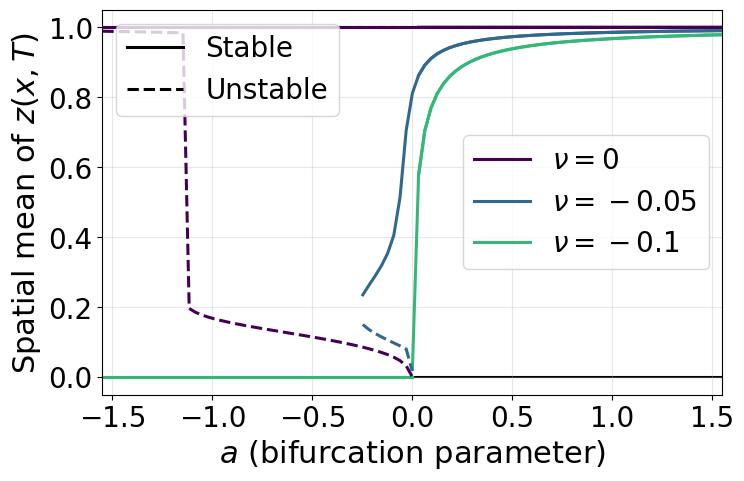

In [130]:
# ============================================================
# Example usage
# ============================================================

lambda12_base = lambda x: 1.0
lambda21 = lambda x: 0.1 - 2 * x**2


nu_values = [0.0, -0.05, -0.1]

fig, ax = overlay_bifurcations_varying_advection(
    nu_values,
    lambda12_base,
    lambda21,
    v_base=lambda x: 1+ 0*x,
    D_func=lambda x: 1e-2 + 0*x,
)
plt.show()

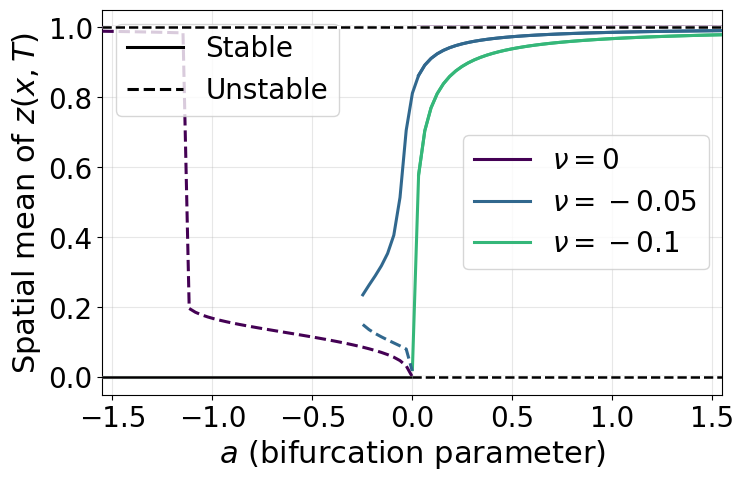

In [131]:
# Get current limits from the existing figure
a_min, a_max = ax.get_xlim()

# Hide whatever is currently at y=1
ax.plot(
    [a_min, a_max],
    [1, 1],
    color="white",
    linewidth=2.2,
    zorder=1000,
    solid_capstyle="butt"
)

# Draw black dashed line on top
ax.plot(
    [a_min, a_max],
    [1, 1],
    color="black",
    linestyle="--",
    linewidth=1.8,
    zorder=1001,
    solid_capstyle="butt"
)

# ------------------------------------------------------
# Cover and redraw z = 0 branch
# solid from -2 to 0, dashed from 0 to 3
# ------------------------------------------------------

# Hide whatever is currently at z=0
ax.plot(
    [-2, 3],
    [0, 0],
    color="white",
    linewidth=2.2,
    zorder=1000,
    solid_capstyle="butt"
)

# Solid black segment from -2 to 0
ax.plot(
    [-2, 0],
    [0, 0],
    color="black",
    linestyle="-",
    linewidth=1.8,
    zorder=1001,
    solid_capstyle="butt"
)

# Dashed black segment from 0 to 3
ax.plot(
    [0, 3],
    [0, 0],
    color="black",
    linestyle="--",
    linewidth=1.8,
    zorder=1001,
    solid_capstyle="butt"
)

plt.show()


# Keep the same x limits
ax.set_xlim(a_min, a_max)

fig

In [132]:
#fig.savefig("advectiononeplot.pdf", bbox_inches="tight")

# Final figure, moving in the $\rho_i^j$ plane

In [56]:
import numpy as np
import matplotlib.pyplot as plt

def plot_principal_eigenvalues_vs_a_additive(
    estimate_principal_eigenvalue_variable_D_advection,
    lambda12_builder,
    lambda21_builder,
    a_vals,
    D_func=lambda x: (1 + 0*x) * 1e-2,
    v_func=lambda x: 0*x,
    N=1001,
    ax=None,
    legend=True,
):
    a_vals = np.asarray(a_vals)

    rho12_vals = []
    rho21_vals = []

    for a in a_vals:
        g12 = lambda x, a=a: lambda12_builder(x, a)
        g21 = lambda x, a=a: lambda21_builder(x, a)

        rho12 = estimate_principal_eigenvalue_variable_D_advection(
            D_func, v_func, g12, N=N
        )
        rho21 = estimate_principal_eigenvalue_variable_D_advection(
            D_func, v_func, g21, N=N
        )

        rho12_vals.append(rho12)
        rho21_vals.append(rho21)

    rho12_vals = np.array(rho12_vals)
    rho21_vals = np.array(rho21_vals)

    if ax is None:
        fig, ax = plt.subplots(figsize=(7, 5))
    else:
        fig = ax.figure

    ax.plot(
        a_vals, rho12_vals,
        color="#5d5d5d",
        linewidth=4,
        linestyle="--",
        label=r"$\rho_1^2(c)$"
    )

    ax.plot(
        a_vals, rho21_vals,
        color="black",
        linewidth=4,
        label=r"$\rho_2^1(c)$"
    )

    ax.set_xlabel(r"$c$")
    ax.set_ylabel(r"$\rho_i^j(c)$")
    ax.set_xlim(a_vals.min(), a_vals.max())

    ymin = min(rho12_vals.min(), rho21_vals.min())
    ymax = max(rho12_vals.max(), rho21_vals.max())
    pad = 0.05 * (ymax - ymin if ymax > ymin else 1.0)
    ax.set_ylim(ymin - pad, ymax + pad)

    ax.grid(True, alpha=0.3)

    if legend:
        ax.legend(frameon=False)

    return fig, ax, rho12_vals, rho21_vals

def find_multiple_steady_states_ab_simulate(
    L=1.0,
    Nx=100,
    D=lambda x: 1e-2 + 0*x,
    lambda12=lambda x: 1 + 0*x,
    a=1.0,
    lambda21=lambda x: 0.5 - 2*x,
    b=1.0,
    guess_range=(0.01, 0.99),
    guess_step=0.05,
    T=1000.0,
    tol_solution=1e-4,
    tol_integral=1e-3,
    tol_duplicate=1e-2,
    v=lambda x: 0*x,
    method="BDF",
):
    import numpy as np
    from scipy.integrate import solve_ivp, simpson

    x = np.linspace(0, L, Nx)
    dx = x[1] - x[0]

    lap = construct_neumann_laplacian_variable_D(Nx, dx, D(x))
    adv = construct_advection_operator(Nx, dx, v(x))

    lam12_vals = a * lambda12(x)
    lam21_vals = b * lambda21(x)

    
    def rhs(t, z):
        reaction = z * (1 - z) * (
            lam12_vals - (lam12_vals + lam21_vals) * z
        )
        return reaction + lap.dot(z) + adv.dot(z)

    guess_values = np.arange(
        guess_range[0], guess_range[1], guess_step
    )

    steady_states = []
    integrals = []

    for guess in guess_values:
        z0 = guess * np.ones(Nx)

        sol = solve_ivp(
            rhs,
            [0, T],
            z0,
            method=method,
            t_eval=[T],
            rtol=1e-4, 
            atol=1e-4
        )

        if not sol.success:
            continue

        z = sol.y[:, -1]

        integral_z = simpson(z, x=x)


        # uniqueness check
        is_new = True
        for z_old in steady_states:
            if np.linalg.norm(z - z_old, ord=np.inf) < tol_duplicate:
                is_new = False
                break

        if is_new:
            steady_states.append(z)
            integrals.append(integral_z)

    return steady_states, x, integrals

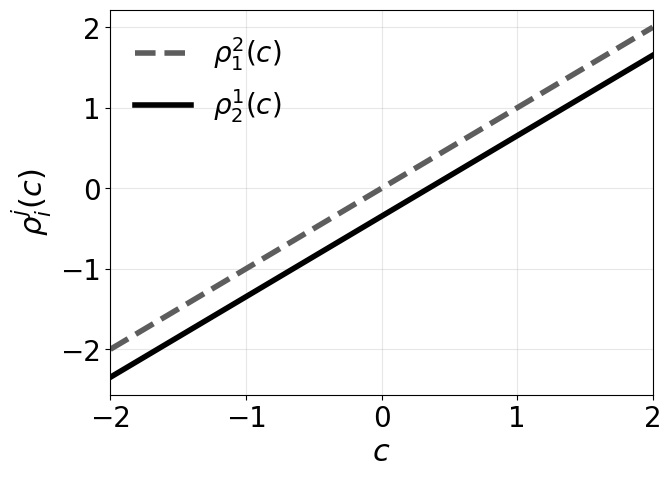

In [57]:
lambda12_builder = lambda x, a: a * (1 + 0*x)   # lambda_1^2 = a
lambda21_builder = lambda x, a: a - 2*x         # lambda_2^1 = a - 2x

D_func = lambda x: (1 + 0*x) * 1e-2
v_func = lambda x: 0*x

a_vals = np.linspace(-2, 2, 51)

fig2, ax, rho12_vals, rho21_vals = plot_principal_eigenvalues_vs_a_additive(
    estimate_principal_eigenvalue_variable_D_advection,
    lambda12_builder=lambda12_builder,
    lambda21_builder=lambda21_builder,
    a_vals=a_vals,
    D_func=D_func,
    v_func=v_func,
    N=1001,
)

plt.show()

In [16]:
import numpy as np


def _make_varied_func(base_func, mode, param, profile_func=None):

    
    def f(x):
        base = base_func(x)
        prof = 1.0 if profile_func is None else profile_func(x)

        if mode == "mult":
            return base * (param * prof)
        elif mode == "lin":
            return base + (param * prof)
        else:
            raise ValueError("mode must be 'mult' or 'lin'")
    return f


def _quadrant(r12, r21):
    if r12 >= 0 and r21 >= 0:
        return 1
    if r12 < 0 and r21 >= 0:
        return 2
    if r12 < 0 and r21 < 0:
        return 3
    return 4


def _region_from_point(r12, r21, multi):
    if r12 >= 0 and r21 >= 0:
        return 1   # Q1
    elif r12 < 0 and r21 >= 0:
        return 2 if multi else 3   # Q2 (multi / single)
    elif r12 < 0 and r21 < 0:
        return 4   # Q3
    else:
        return 5   # Q4


def compute_hetero_ab_data(
    lambda12_builder,
    lambda21_builder,

    D_base=lambda x: (1 + 0*x) * 1e-2,
    v_base=lambda x: 0*x,

    a_vals=None,
    b_vals=None,

    D_params=None,
    v_params=None,
    D_mode="mult",
    v_mode="lin",
    D_profile=None,
    v_profile=None,

    a_fixed=1.0,
    b_fixed=1.0,

    principal_eig_func=None,
    eigN=1001,
    find_steady_states_func=None,
    Nx=200,
):
    """
    Compute transformed points and classifications without plotting.

    Parameters
    ----------
    lambda12_builder : callable
        Function of the form lambda12_builder(x, a), returning lambda_1^2(x; a)
    lambda21_builder : callable
        Function of the form lambda21_builder(x, b), returning lambda_2^1(x; b)

    Returns
    -------
    out : dict
        out["grid"], out["D"], out["v"]
    """

    if principal_eig_func is None:
        raise ValueError("Provide principal_eig_func.")
    if find_steady_states_func is None:
        raise ValueError("Provide find_steady_states_func.")

    def classify_point(a, b, D_func, v_func):
        lam12 = lambda x, a=a: lambda12_builder(x, a)
        lam21 = lambda x, b=b: lambda21_builder(x, b)

        r12 = principal_eig_func(D_func, v_func, lam12, N=eigN)
        r21 = principal_eig_func(D_func, v_func, lam21, N=eigN)

        steady_states, _, _ = find_steady_states_func(
            L=1.0,
            Nx=Nx,
            D=D_func,
            v=v_func,
            lambda12=lam12,
            lambda21=lam21,
        )

        multi = (len(steady_states) > 1)
        region = _region_from_point(r12, r21, multi)

        return {
            "a": a,
            "b": b,
            "r12": r12,
            "r21": r21,
            "multi": multi,
            "region": region,
        }

    out = {
        "grid": None,
        "D": None,
        "v": None,
    }

    # --------------------------------------------------
    # 1) GRID OF (a,b) VALUES WITH BASELINE D AND v
    # --------------------------------------------------
    if a_vals is not None and b_vals is not None:
        grid_records = []
        for a in a_vals:
            for b in b_vals:
                grid_records.append(classify_point(a, b, D_base, v_base))

        out["grid"] = {
            "records": grid_records,
            "a_vals": np.array(a_vals, dtype=float),
            "b_vals": np.array(b_vals, dtype=float),
            "r12": np.array([rec["r12"] for rec in grid_records], dtype=float),
            "r21": np.array([rec["r21"] for rec in grid_records], dtype=float),
            "region": np.array([rec["region"] for rec in grid_records], dtype=int),
            "multi": np.array([rec["multi"] for rec in grid_records], dtype=bool),
        }

    # --------------------------------------------------
    # 2) OPTIONAL: VARY D AT FIXED (a_fixed, b_fixed)
    # --------------------------------------------------
    if D_params is not None:
        D_records = []
        for Dp in D_params:
            Dv = _make_varied_func(D_base, D_mode, Dp, profile_func=D_profile)
            rec = classify_point(a_fixed, b_fixed, Dv, v_base)
            rec["param"] = Dp
            D_records.append(rec)

        out["D"] = {
            "records": D_records,
            "params": np.array(D_params, dtype=float),
            "r12": np.array([rec["r12"] for rec in D_records], dtype=float),
            "r21": np.array([rec["r21"] for rec in D_records], dtype=float),
            "region": np.array([rec["region"] for rec in D_records], dtype=int),
        }

    # --------------------------------------------------
    # 3) OPTIONAL: VARY v AT FIXED (a_fixed, b_fixed)
    # --------------------------------------------------
    if v_params is not None:
        v_records = []
        for vp in v_params:
            vv = _make_varied_func(v_base, v_mode, vp, profile_func=v_profile)
            rec = classify_point(a_fixed, b_fixed, D_base, vv)
            rec["param"] = vp
            v_records.append(rec)

        out["v"] = {
            "records": v_records,
            "params": np.array(v_params, dtype=float),
            "r12": np.array([rec["r12"] for rec in v_records], dtype=float),
            "r21": np.array([rec["r21"] for rec in v_records], dtype=float),
            "region": np.array([rec["region"] for rec in v_records], dtype=int),
        }

    return out

Generate or import data

In [38]:
lambda12_builder = lambda x, a: a + 0*x
lambda21_builder = lambda x, b: b - 2*x

a_vals = np.arange(-2, 2, 0.1)
b_vals = np.arange(-2, 2, 0.1)

data = compute_hetero_ab_data(
    lambda12_builder=lambda12_builder,
    lambda21_builder=lambda21_builder,
    a_vals=a_vals,
    b_vals=b_vals,
    D_base=lambda x: 1e-2 + 0*x,
    v_base=lambda x: 0*x,
    principal_eig_func=estimate_principal_eigenvalue_variable_D_advection,
    find_steady_states_func=find_multiple_steady_states_ab_simulate,
    eigN=1001,
    Nx=200,
)

In [39]:
import pickle

with open("hetero_ab_additive.pkl", "wb") as f:
    pickle.dump(data, f)

with open("hetero_ab_additive.pkl", "rb") as f:
    data = pickle.load(f)

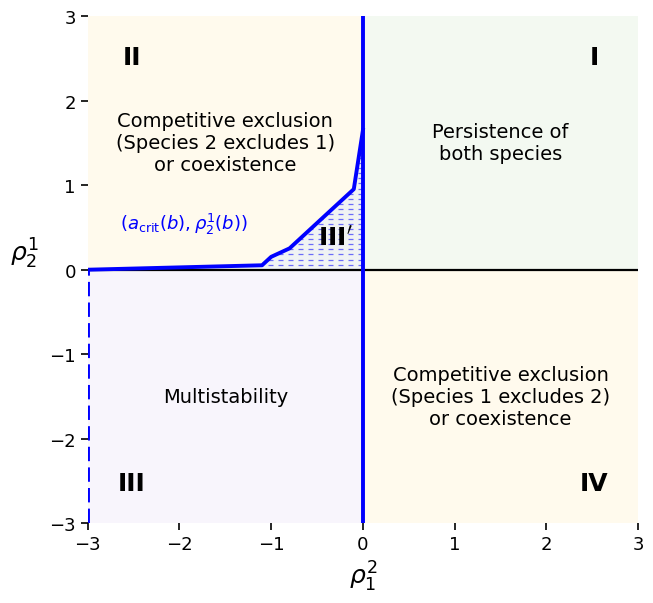

In [62]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle, Polygon

# ===================================================
# 1. Compute the parametric curve
# ===================================================

records = data["grid"]["records"]

# ---------------------------
# Keep only region 2 points
# For each b, take min a
# ---------------------------
region2_points = [
    rec for rec in records
    if rec["region"] == 2
]

min_a_by_b_region2 = {}

for rec in region2_points:
    a = rec["a"]
    b = rec["b"]

    if b not in min_a_by_b_region2 or a < min_a_by_b_region2[b]:
        min_a_by_b_region2[b] = a

# Points are (a_cross, b), sorted by b
region2_cross_points = [
    (a_cross, b)
    for b, a_cross in sorted(min_a_by_b_region2.items())
]

a_cross_region2 = np.array([
    a_cross for a_cross, b in region2_cross_points
])

b_region2 = np.array([
    b for a_cross, b in region2_cross_points
])


# ---------------------------
# Compute rho_2^1(b)
# including endpoints b=-2 and b=2
# ---------------------------
lambda12_builder = lambda x, b: b * (1 + 0*x)   # dummy here
lambda21_builder = lambda x, b: b - 2*x         # lambda_2^1 = b - 2x

D_func = lambda x: (1 + 0*x) * 1e-2
v_func = lambda x: 0*x

b_all = np.concatenate([
    np.array([-2]),
    b_region2,
    np.array([2])
])

fig_tmp, ax_tmp, rho12_dummy, rho21_all = plot_principal_eigenvalues_vs_a_additive(
    estimate_principal_eigenvalue_variable_D_advection,
    lambda12_builder=lambda12_builder,
    lambda21_builder=lambda21_builder,
    a_vals=b_all,
    D_func=D_func,
    v_func=v_func,
    N=1001,
)

plt.close(fig_tmp)

rho21_all = np.array(rho21_all)

rho_b_minus_2 = rho21_all[0]
rho21_region2 = rho21_all[1:-1]
rho_b_plus_2 = rho21_all[-1]


# ===================================================
# 2. Build the curve
# x = rho_1^2 = a_cross
# y = rho_2^1
# ===================================================

curve_color = "blue"

# Artificial left branch representing rho_1^2 -> -infinity.
# It is drawn at x = -3 because the visible axis stops there.
a_left_inf = np.array([-3, -3])
rho_left_inf = np.array([-3, 0])

# Main parametric curve.
# Extra starting point placed at a = -3, rho_2^1 = 0.
a_curve = np.concatenate([
    np.array([-3]),
    a_cross_region2,
    np.array([0])
])

rho_curve = np.concatenate([
    np.array([0]),
    rho21_region2,
    np.array([rho_b_plus_2])
])

# Vertical branch at rho_1^2 = 0.
# Drawn from rho_2^1 = -3 to rho_2^1(b=2).
a_right = np.array([0, 0])
rho_right = np.array([-3, 3])


# ===================================================
# 3. Plot heterogeneous panel from -3 to 3
# ===================================================

color_coexistence = '#dff0d8'
color_multistability = '#ece3f8'
color_amber = '#fff3cd'

title_fs = 18
label_fs = 18
text_fs = 14
quad_fs = 18

figB, ax = plt.subplots(figsize=(7, 6.5))

x_min, x_max = -3, 3
y_min, y_max = -3, 3

# ---------------------------
# Background quadrants
# ---------------------------
ax.add_patch(Rectangle(
    (0, 0), x_max, y_max,
    facecolor=color_coexistence,
    alpha=0.35,
    zorder=0
))

ax.add_patch(Rectangle(
    (x_min, y_min), -x_min, -y_min,
    facecolor=color_multistability,
    alpha=0.35,
    zorder=0
))

ax.add_patch(Rectangle(
    (0, y_min), x_max, -y_min,
    facecolor=color_amber,
    alpha=0.35,
    zorder=0
))

ax.add_patch(Rectangle(
    (x_min, 0), -x_min, y_max,
    facecolor=color_amber,
    alpha=0.35,
    zorder=0
))


# ---------------------------
# Region III': quadrant II below the blue curve
# ---------------------------

# Follow the blue curve from (-3, 0) to (0, rho_max),
# then return along the vertical and horizontal axes.
III_prime_vertices = np.vstack([
    np.column_stack([a_curve, rho_curve]),
    [0, 0],
    [x_min, 0],
])

III_prime_patch = Polygon(
    III_prime_vertices,
    closed=True,
    facecolor="#dbeafe",   # light blue background
    edgecolor="none",
    alpha=0.40,
    zorder=1,
)

ax.add_patch(III_prime_patch)

# Add genuinely dashed blue horizontal lines and clip them
# so that they only appear inside region III'.
stripe_spacing = 0.06

for y_stripe in np.arange(
    stripe_spacing,
    min(y_max, np.max(rho_curve)),
    stripe_spacing
):
    stripe, = ax.plot(
        [x_min, 0],
        [y_stripe, y_stripe],
        color=curve_color,
        linewidth=0.9,
        linestyle=(0, (4, 4)),
        alpha=0.55,
        zorder=1.5,
    )

    stripe.set_clip_path(III_prime_patch)
    
# Central axes
ax.axhline(0, color='black', linewidth=1.6, zorder=2)
ax.axvline(0, color='black', linewidth=1.6, zorder=2)

# ---------------------------
# Overlay parametric curve
# ---------------------------

# Dashed branch at a = -3, representing continuation to -infinity
ax.plot(
    a_left_inf,
    rho_left_inf,
    color=curve_color,
    linewidth=2.8,
    linestyle="--",
    zorder=5
)

# Main parametric curve
ax.plot(
    a_curve,
    rho_curve,
    color=curve_color,
    linewidth=2.8,
    zorder=5
)

# Vertical branch at rho_1^2 = 0
ax.plot(
    a_right,
    rho_right,
    color=curve_color,
    linewidth=2.8,
    zorder=5
)

ax.annotate(
    r'$(a_{\rm crit}(b),\rho_2^1(b))$',
    xy=(-0.75, 0.45),          # point on/near the curve
    xytext=(-2.65, 0.55),      # label position
    color=curve_color,
    fontsize=13,
    ha='left',
    va='center',
    # arrowprops=dict(
    #     arrowstyle='->',
    #     color=curve_color,
    #     lw=1.5
    # ),
    zorder=10
)

# Limits
ax.set_xlim(x_min, x_max)
ax.set_ylim(y_min, y_max)

# Ticks and numbers
ax.set_xticks(np.arange(x_min, x_max + 1, 1))
ax.set_yticks(np.arange(y_min, y_max + 1, 1))

ax.tick_params(
    axis='both',
    which='major',
    direction='out',
    length=5,
    width=1.2,
    labelsize=13
)


# Remove box
for spine in ax.spines.values():
    spine.set_visible(False)

# Titles and labels
#ax.set_title('Heterogeneous', fontsize=title_fs, fontweight='bold', pad=18)
ax.set_xlabel(r'$\rho_1^2$', fontsize=label_fs)
ax.set_ylabel(r'$\rho_2^1$', fontsize=label_fs, rotation=0, labelpad=18)

# Roman numerals
ax.text(0.92, 0.92, 'I', transform=ax.transAxes, fontsize=quad_fs,
        fontweight='bold', ha='center', va='center')

ax.text(0.08, 0.92, 'II', transform=ax.transAxes, fontsize=quad_fs,
        fontweight='bold', ha='center', va='center')

ax.text(0.08, 0.08, 'III', transform=ax.transAxes, fontsize=quad_fs,
        fontweight='bold', ha='center', va='center')

ax.text(0.92, 0.08, 'IV', transform=ax.transAxes, fontsize=quad_fs,
        fontweight='bold', ha='center', va='center')

ax.text(-0.30, 0.38, r"$\mathbf{III}^{\prime}$", fontsize=quad_fs, 
        fontweight="bold", ha="center", va="center", zorder=10)

# Region labels
ax.text(1.5, 1.5,
        'Persistence of\nboth species',
        ha='center', va='center', fontsize=text_fs)

ax.text(-1.5, -1.5,
        'Multistability',
        ha='center', va='center', fontsize=text_fs)

ax.text(1.5, -1.5,
        'Competitive exclusion\n(Species 1 excludes 2)\nor coexistence',
        ha='center', va='center', fontsize=text_fs)

ax.text(-1.5, 1.5,
        'Competitive exclusion\n(Species 2 excludes 1)\nor coexistence',
        ha='center', va='center', fontsize=text_fs)

plt.tight_layout()
#plt.savefig("heterogeneous_with_parametric_curve_blue.pdf", bbox_inches="tight")
plt.show()